In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.gridspec as gridspec

from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from tslearn.clustering import TimeSeriesKMeans

/opt/anaconda3/envs/OB/lib/python3.13/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## Read Data
use two year data for post-covid representation

In [2]:
# Load Data
data2023        = pd.read_csv('atusact-2023/atusact_2023.dat',   dtype={'TRCODE': str, 'TUCASEID': str})
respondents2023 = pd.read_csv('atusresp-2023/atusresp_2023.dat', dtype={'TUCASEID': str})
jointed2023     = pd.merge(data2023, respondents2023, on='TUCASEID', how='inner')
jointed2023['year'] = 2023

data2024        = pd.read_csv('atusact-2024/atusact_2024.dat',   dtype={'TRCODE': str, 'TUCASEID': str})
respondents2024 = pd.read_csv('atusresp-2024/atusresp_2024.dat', dtype={'TUCASEID': str})
jointed2024     = pd.merge(data2024, respondents2024, on='TUCASEID', how='inner')
jointed2024['year'] = 2024

joined_data = pd.concat([jointed2023, jointed2024], ignore_index=True)

keep_cols = [
    'TUCASEID', 'TUDIARYDAY', 'TUFINLWGT', 'year',
    'TESCHENR', 'TESCHFT', 'TESCHLVL',
    'TRHHCHILD', 'TRDPFTPT', 'TELFS', 'TRTHH', 'TEAGE',
    'TRCODE', 'TUACTDUR', 'TUSTARTTIM', 'TUSTOPTIME', 'TEWHERE',
]
joined_data = joined_data[[c for c in keep_cols if c in joined_data.columns]]

# Day type
joined_data['daytype'] = joined_data['TUDIARYDAY'].map(
    lambda d: 'weekend' if d in (1, 7) else 'weekday'
)
print(f'Loaded {joined_data["TUCASEID"].nunique():,} respondents, {len(joined_data):,} activity rows')

Loaded 16,217 respondents, 292,655 activity rows


## Clean Data 

In [3]:
def map_state(row):
    if str(row['TRCODE']).startswith('0101'):
        return 'sleep'
    elif row['TEWHERE'] == 1:
        return 'home'
    else:
        return 'away'

joined_data['state'] = joined_data.apply(map_state, axis=1)

joined_data['daytype'] = joined_data['TUDIARYDAY'].map(
    lambda d: 'weekend' if d in (1, 7) else 'weekday'
)

In [4]:
DIARY_START = 4 * 60  # 4am = 240 min; this is t=0 in our coordinate system

def parse_atus_time(t):
    """Parse 'HH:MM' or 'HH:MM:SS' → minutes since 4am. Times before 4am are post-midnight (+1440)."""
    parts = str(t).strip().split(':')
    h, m = int(parts[0]), int(parts[1])
    minutes = h * 60 + m
    if minutes < DIARY_START:
        minutes += 1440          # post-midnight, belongs to next side of diary
    return minutes - DIARY_START  # shift so 4am = 0

joined_data['start_min'] = joined_data['TUSTARTTIM'].apply(parse_atus_time)
joined_data['stop_min']  = joined_data['TUSTOPTIME'].apply(parse_atus_time)

# If an activity crosses midnight and ends after 4am, stop_min will appear < start_min
# (e.g. sleep 9pm→8am: start=1032, stop=240). Add 1440 to fix.
mask = joined_data['stop_min'] < joined_data['start_min']
joined_data.loc[mask, 'stop_min'] += 1440

# Sort activities within each respondent
joined_data = joined_data.sort_values(['TUCASEID', 'start_min']).reset_index(drop=True)

# Identify consecutive same-state runs per respondent
joined_data['state_grp'] = (
    joined_data.groupby('TUCASEID')['state']
    .transform(lambda s: (s != s.shift()).cumsum())
)

# Collapse into state episodes
state_episodes = (
    joined_data
    .groupby(['TUCASEID', 'daytype', 'state_grp'], sort=False)
    .agg(
        state    = ('state', 'first'),
        start_min= ('start_min', 'min'),
        stop_min = ('stop_min',  'max'),
    )
    .reset_index()
    .drop(columns='state_grp')
)
state_episodes['duration'] = state_episodes['stop_min'] - state_episodes['start_min']


## Clustering — Weekday vs Weekend

In [5]:
STATE_MAP  = {'sleep': 0, 'home': 0, 'away': 1}
DIARY_LEN  = 24 * 60  # 1440 bins, one per minute from 4am to 4am
BIN_SIZE   = 30      # minutes per coarse bin
N_BINS     = DIARY_LEN // BIN_SIZE  # 288 bins

def episodes_to_vector(episodes):
    """Convert a respondent's state episodes into a 1440-bin array (cap at 1440)."""
    vec = np.full(DIARY_LEN, -1, dtype=np.int8)  # -1 = unrecorded
    for _, row in episodes.iterrows():
        start = int(np.clip(row['start_min'], 0, DIARY_LEN))
        stop  = int(np.clip(row['stop_min'],  0, DIARY_LEN))
        vec[start:stop] = STATE_MAP[row['state']]
    return vec

def coarsen_vector(vec):
    """Downsample 1440-bin vector to 288 bins by majority vote (ignoring -1)."""
    coarse = np.full(N_BINS, -1, dtype=np.int8)
    for i in range(N_BINS):
        window = vec[i * BIN_SIZE : (i + 1) * BIN_SIZE]
        recorded = window[window >= 0]
        if len(recorded) > 0:
            coarse[i] = np.bincount(recorded, minlength=3).argmax()
    return coarse

records = []
for (caseid, daytype), grp in state_episodes.groupby(['TUCASEID', 'daytype']):
    vec    = episodes_to_vector(grp)
    coarse = coarsen_vector(vec)
    records.append({'TUCASEID': caseid, 'daytype': daytype, 'vec': coarse})

state_vectors = pd.DataFrame(records)
print(state_vectors.shape)
state_vectors.head()


(16217, 3)


,TUCASEID,daytype,vec
0,20230101230035,weekday,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, ..."
1,20230101230077,weekend,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
2,20230101230105,weekend,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,20230101230522,weekend,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ..."
4,20230101230524,weekday,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [6]:


def prepare_2state(df_daytype):
    """Remap sleep+home→0, away→1, ffill gaps, return (n, 96, 1) array."""
    vecs = np.stack(df_daytype['vec'].values).astype(float)   # (n, 96), values 0/1/2/-1

    # Remap to binary
    vecs = np.where(vecs < 0, np.nan, vecs)

    # Forward-fill NaN along time axis, then backward-fill leading NaNs
    for i in range(len(vecs)):
        row = vecs[i]
        mask = ~np.isnan(row)
        if mask.sum() == 0:
            continue
        idx = np.where(mask, np.arange(len(row)), 0)
        np.maximum.accumulate(idx, out=idx)
        row = row[idx]
        vecs[i] = row

    # Drop all-NaN respondents
    valid = ~np.any(np.isnan(vecs), axis=1)
    vecs  = vecs[valid].astype(np.float32)
    caseids = df_daytype['TUCASEID'].values[valid]

    return vecs[:, :, np.newaxis], caseids   # (n, 96, 1)

wd_df = state_vectors[state_vectors['daytype'] == 'weekday'].reset_index(drop=True)
we_df = state_vectors[state_vectors['daytype'] == 'weekend'].reset_index(drop=True)

X_wd, ids_wd = prepare_2state(wd_df)
X_we, ids_we = prepare_2state(we_df)

print(f'Weekday: {X_wd.shape}')
print(f'Weekend: {X_we.shape}')


Weekday: (8203, 48, 1)
Weekend: (8014, 48, 1)


In [7]:



def quick_cluster(X, label, k):
    Xs = X[:, :, 0]   # (n, N_BINS)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)

    peak_away = [Xs[labels == c].mean(axis=0).argmax() for c in range(k)]
    order = np.argsort(peak_away)

    xticks = np.arange(0, N_BINS + 1, 8)
    xlabels = [f'{(4 + t * BIN_SIZE // 60) % 24:02d}:00' for t in xticks]

    fig, axes = plt.subplots(1, k, figsize=(4 * k, 3), sharey=True)
    for plot_i, c in enumerate(order):
        ax = axes[plot_i]
        centroid = km.cluster_centers_[c]
        n_c = (labels == c).sum()
        ax.fill_between(range(N_BINS), centroid, 1, color='#ffffff', alpha=0.85)
        ax.fill_between(range(N_BINS), 0, centroid, color='#587abe', alpha=0.85)
        ax.set_title(f'Cluster {plot_i+1}\n(n={n_c})')
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabels, rotation=45, ha='right')
        ax.set_ylim(0, 1)
        ax.set_xlim(0, N_BINS - 1)
        if plot_i == 0:
            ax.set_ylabel('P(away)')

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#ffffff", "#587abe"]]
    fig.legend(handles, ['Away', 'Home'], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle(f'{label} — quick euclidean k={k}', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    return km, labels, order

def centroid_distance_matrix(km, order=None, metric='euclidean'):
    C = km.cluster_centers_   # (k, N_BINS)

    if order is not None:
        C = C[order]

    D = squareform(pdist(C, metric=metric))
    return C, D


In [8]:
def quick_cluster_2row(X, label, k):
    """Same as quick_cluster but arranges subplots in 2 rows × (k//2) columns."""
    assert k % 2 == 0, "k must be divisible by 2"
    Xs = X[:, :, 0]   # (n, N_BINS)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)

    peak_away = [Xs[labels == c].mean(axis=0).argmax() for c in range(k)]
    order = np.argsort(peak_away)

    xticks = np.arange(0, N_BINS + 1, 8)
    xlabels = [f'{int((4 + t * BIN_SIZE / 60) % 24)}' for t in xticks]

    cols = k // 2
    fig, axes = plt.subplots(2, cols, figsize=(4 * cols, 6), sharey=True)

    for plot_i, c in enumerate(order):
        row, col = divmod(plot_i, cols)
        ax = axes[row, col]
        centroid = km.cluster_centers_[c]
        n_c = (labels == c).sum()
        ax.fill_between(range(N_BINS), centroid, 1, color='#ffffff', alpha=0.85)
        ax.fill_between(range(N_BINS), 0, centroid, color='#587abe', alpha=0.85)
        ax.set_title(f'Cluster {plot_i+1}\n(n={n_c})')
        ax.set_xticks(xticks)
        ax.set_xticklabels(xlabels, rotation=0, ha='right')
        ax.set_ylim(0, 1)
        ax.set_xlim(0, N_BINS - 1)
        if col == 0:
            ax.set_ylabel('P(away)')

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ['#ffffff', '#587abe']]
    fig.legend(handles, ['Away', 'Home'], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
    #fig.suptitle(f'{label} — quick euclidean k={k} (2-row)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    return km, labels, order


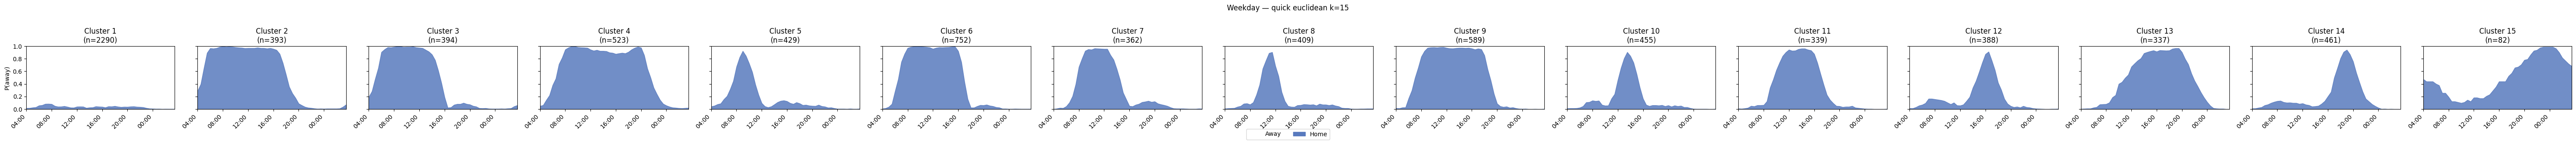

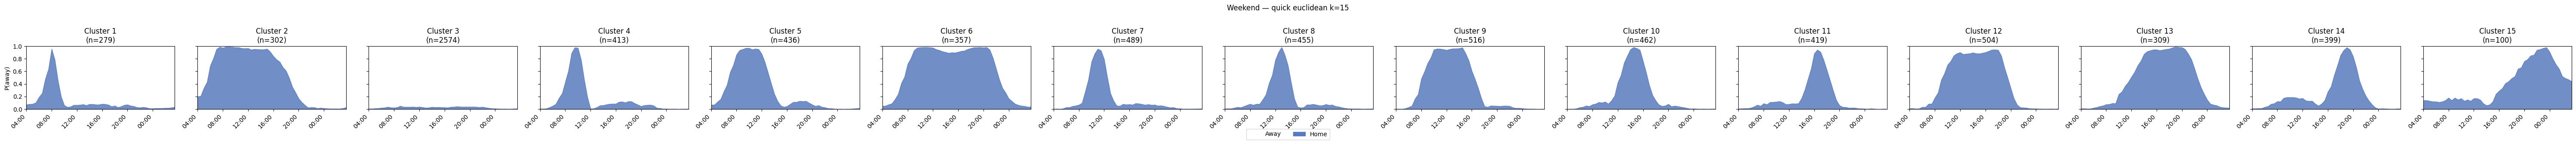

In [9]:
km_wd, labels_wd, order_wd = quick_cluster(X_wd, 'Weekday', k=15)
C_wd, D_wd = centroid_distance_matrix(km_wd, order=order_wd, metric='euclidean')

km_we, labels_we, order_we = quick_cluster(X_we, 'Weekend', k=15)
C_we, D_we = centroid_distance_matrix(km_we, order=order_we, metric='euclidean')

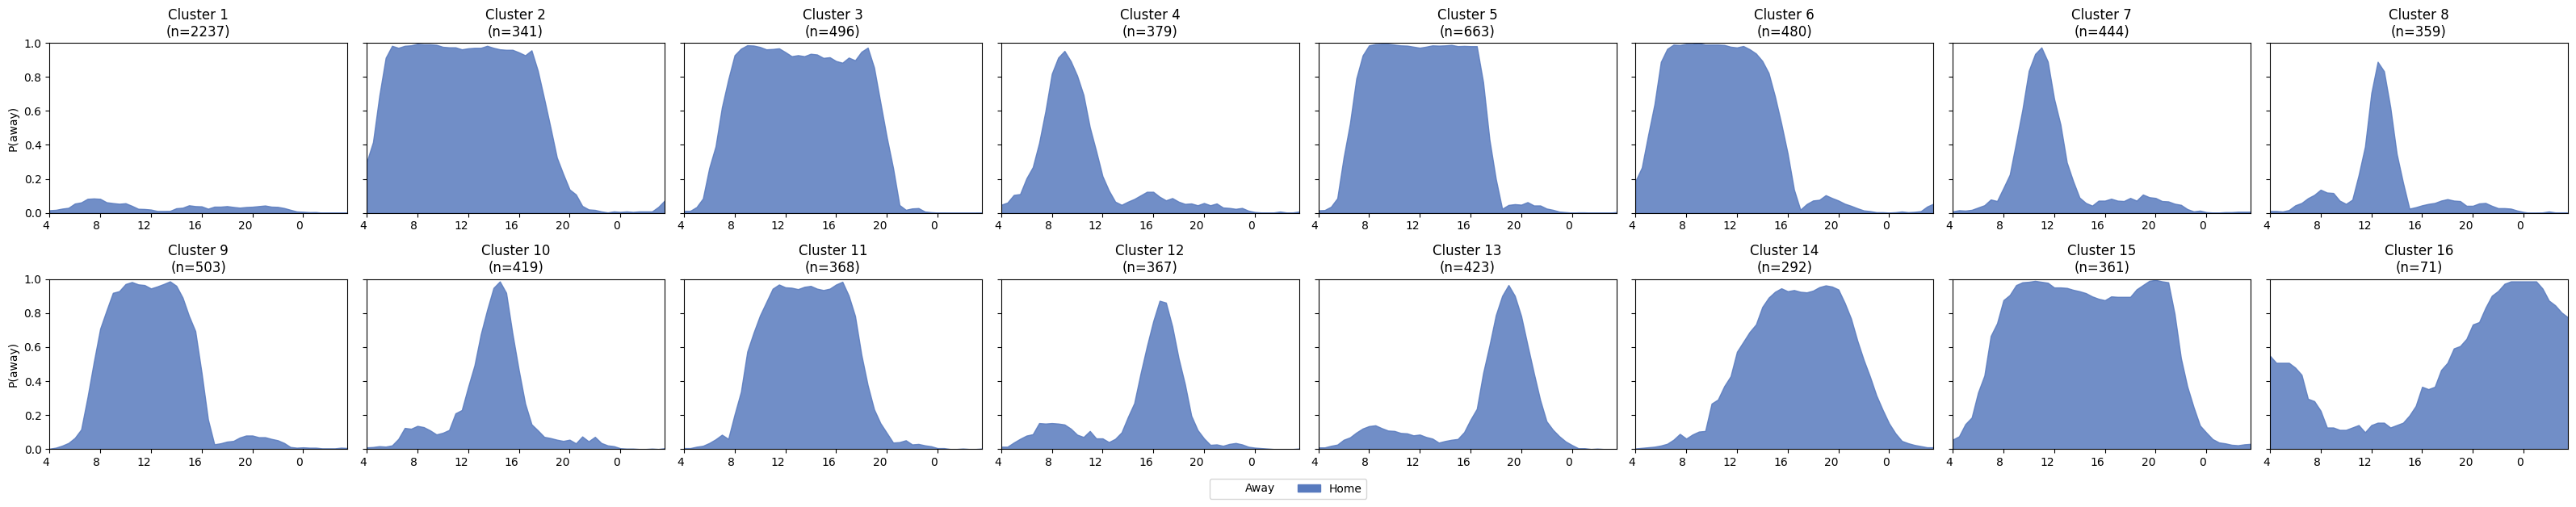

In [ ]:
# km_wd, labels_wd, order_wd = quick_cluster_2row(X_wd, 'Weekday', k=16)
# C_wd, D_wd = centroid_distance_matrix(km_wd, order=order_wd, metric='euclidean')

Weekday semantic sizes (from 15 clusters):
  Mostly Home: 2,290
  Long Day Away: 3,327
  Morning Out: 1,655
  Afternoon Out: 849
  Evening/Night Away: 82
Weekend semantic sizes (from 15 clusters):
  Mostly Home: 2,574
  Long Day Away: 1,472
  Morning Out: 2,588
  Afternoon Out: 1,280
  Evening/Night Away: 100


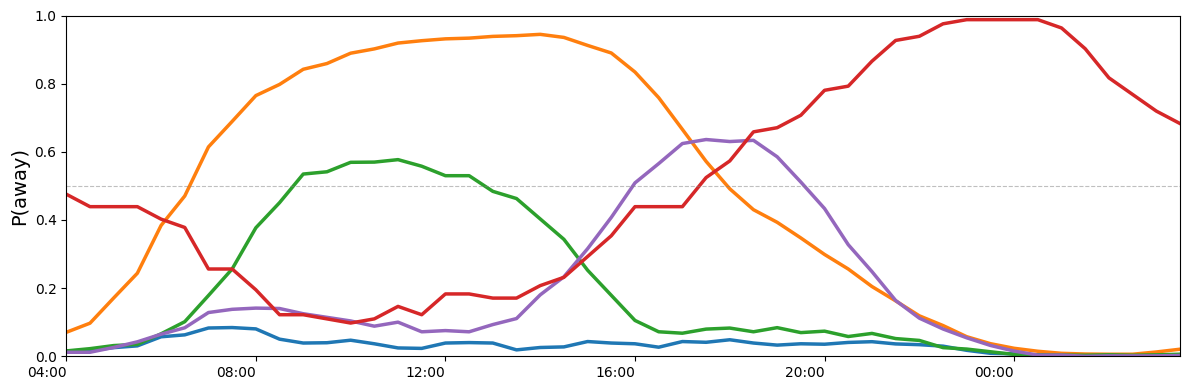

In [10]:
# ── Manual semantic merge of the 15 raw clusters ─────────────────────────────
# Ranks 0–14 are ordered by peak-away time (see plots above).
# Fill in each rank → semantic group:
#   0 = Mostly Home  |  1 = Long Day Away  |  2 = Morning Out
#   3 = Afternoon Out  |  4 = Evening/Night Away

SEMANTIC_NAMES = {
    0: 'Mostly Home',
    1: 'Long Day Away',
    2: 'Morning Out',
    3: 'Afternoon Out',
    4: 'Evening/Night Away',
}

# ── EDIT THESE based on the cluster plots above ───────────────────────────────
WD_RANK15_TO_SEM = {
    0:  0,   # rank 0  → ??? 
    1:  1,   # rank 1  → ???
    2:  1,   # rank 2  → ???
    3:  1,   # rank 3  → ???
    4:  2,   # rank 4  → ???
    5:  1,   # rank 5  → ???
    6:  2,   # rank 6  → ???
    7:  2,   # rank 7  → ???
    8:  1,   # rank 8  → ???
    9:  2,   # rank 9  → ???
    10: 1,   # rank 10 → ???
    11: 3,   # rank 11 → ???
    12: 1,   # rank 12 → ???
    13: 3,   # rank 13 → ???
    14: 4,   # rank 14 → ???
}

WE_RANK15_TO_SEM = {
    0:  2,
    1:  1,
    2:  0,
    3:  2,
    4:  2,
    5:  1,
    6:  2,
    7:  2,
    8:  2,
    9:  3,
    10: 3,
    11: 1,
    12: 1,
    13: 3,
    14: 4,
}
# ─────────────────────────────────────────────────────────────────────────────

def rank_to_sem_labels(labels, order, rank_to_sem):
    """Map raw cluster labels → semantic labels via rank order."""
    raw_to_rank = {int(raw): rank for rank, raw in enumerate(order)}
    raw_to_sem  = {raw: rank_to_sem[rank] for raw, rank in raw_to_rank.items()}
    return np.array([raw_to_sem[int(l)] for l in labels], dtype=int)

labels_sem15_wd = rank_to_sem_labels(labels_wd, order_wd, WD_RANK15_TO_SEM)
labels_sem15_we = rank_to_sem_labels(labels_we, order_we, WE_RANK15_TO_SEM)

print('Weekday semantic sizes (from 15 clusters):')
for s in range(5):
    print(f'  {SEMANTIC_NAMES[s]}: {(labels_sem15_wd == s).sum():,}')
print('Weekend semantic sizes (from 15 clusters):')
for s in range(5):
    print(f'  {SEMANTIC_NAMES[s]}: {(labels_sem15_we == s).sum():,}')

# ── Plot merged centroids ─────────────────────────────────────────────────────
sem_cmap = {
    0: '#1f77b4',  # Mostly Home
    1: '#ff7f0e',  # Long Day Away
    2: '#2ca02c',  # Morning Out
    3: '#9467bd',  # Afternoon Out
    4: '#d62728',  # Evening/Night Away
}

xticks  = np.arange(0, N_BINS + 1, 8)
xlabels = [f'{(4 + t * BIN_SIZE // 60) % 24:02d}:00' for t in xticks]

fig, ax = plt.subplots(figsize=(12, 4))
X2d = X_wd[:, :, 0]
for s in range(5):
    mask = labels_sem15_wd == s
    if mask.sum() == 0:
        continue
    centroid = X2d[mask].mean(axis=0)
    ax.plot(range(N_BINS), centroid, color=sem_cmap[s],
            linewidth=2.5, label=f'{SEMANTIC_NAMES[s]} (n={mask.sum():,})')
#ax.set_title('Weekday')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=0, ha='right')
ax.set_ylim(0, 1); ax.set_xlim(0, N_BINS - 1)
ax.set_ylabel('P(away)', fontsize=14)
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
#ax.legend(fontsize=12)

#fig.suptitle('Semantic centroids (manual merge of 15 clusters) — P(away) by time of day',fontsize=12)
plt.tight_layout()
plt.show()


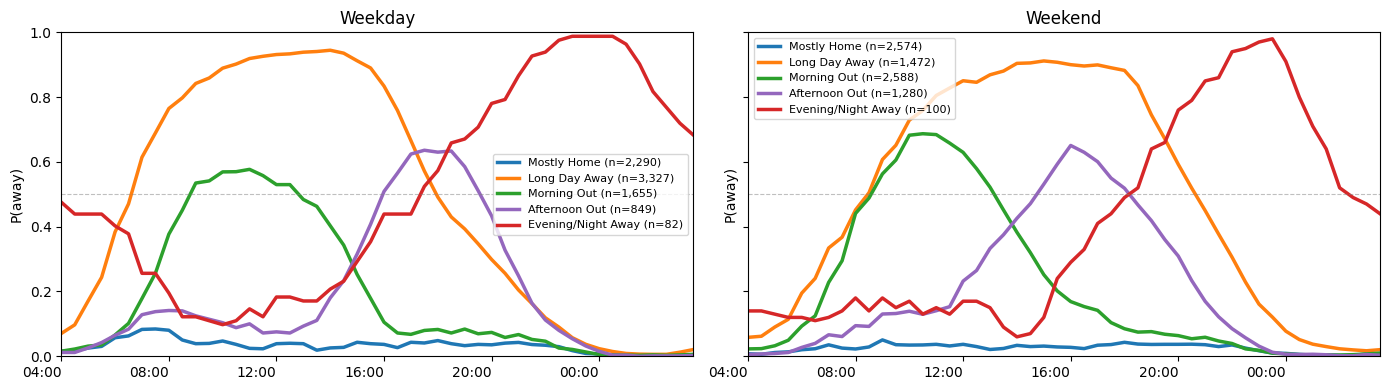

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, X, labels_sem, title in [
    (axes[0], X_wd, labels_sem15_wd, 'Weekday'),
    (axes[1], X_we, labels_sem15_we, 'Weekend'),
]:
    X2d = X[:, :, 0]
    for s in range(5):
        mask = labels_sem == s
        if mask.sum() == 0:
            continue
        centroid = X2d[mask].mean(axis=0)
        ax.plot(range(N_BINS), centroid, color=sem_cmap[s],
                linewidth=2.5, label=f'{SEMANTIC_NAMES[s]} (n={mask.sum():,})')
    ax.set_title(title)
    ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=0, ha='right')
    ax.set_ylim(0, 1); ax.set_xlim(0, N_BINS - 1)
    ax.set_ylabel('P(away)')
    ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Cluster Demographics

In [11]:
# Load demographics from respondents + roster files
resp_cols = ['TUCASEID', 'TELFS', 'TESCHENR', 'TRDPFTPT',
             'TRHHCHILD', 'TRNHHCHILD', 'TRNUMHOU',
             'TRSPPRES', 'TEIO1COW', 'TRMJIND1', 'TRMJOCC1', 'TREMODR']

resp23 = pd.read_csv('atusresp-2023/atusresp_2023.dat', dtype={'TUCASEID': str})
resp24 = pd.read_csv('atusresp-2024/atusresp_2024.dat', dtype={'TUCASEID': str})
resp   = pd.concat([resp23, resp24], ignore_index=True)
resp   = resp[[c for c in resp_cols if c in resp.columns]].drop_duplicates('TUCASEID')

rost23 = pd.read_csv('atusrost-2023/atusrost_2023.dat', dtype={'TUCASEID': str})
rost24 = pd.read_csv('atusrost-2024/atusrost_2024.dat', dtype={'TUCASEID': str})
rost   = pd.concat([rost23, rost24], ignore_index=True)
rost   = rost[rost['TULINENO'] == 1][['TUCASEID', 'TEAGE', 'TESEX']].drop_duplicates('TUCASEID')

demo = resp.merge(rost, on='TUCASEID', how='left')
print(f'Demo table: {demo.shape},  columns: {list(demo.columns)}')

# Label maps
telfs_map   = {1: 'Emp-at work', 2: 'Emp-absent', 3: 'Unemp-layoff',
               4: 'Unemp-looking', 5: 'Not in LF'}
cowmap      = {1: 'Govt-federal', 2: 'Govt-state', 3: 'Govt-local',
               4: 'Private', 5: 'Self-emp (inc)', 6: 'Self-emp (not inc)', 7: 'Unpaid/other'}
remotemap   = {1: 'Telework day', 2: 'Non-telework', -1: 'N/A'}
sspresmap   = {1: 'Spouse present', 2: 'Unmarried partner', 3: 'No partner'}

def make_demo_df(ids, labels, daytype):
    df = pd.DataFrame({'TUCASEID': ids, 'cluster': labels})
    df = df.merge(demo, on='TUCASEID', how='left')
    df['daytype'] = daytype
    return df

demo_wd = make_demo_df(ids_wd, labels_sem15_wd, 'Weekday')
demo_we = make_demo_df(ids_we, labels_sem15_we, 'Weekend')
print('Weekday:', demo_wd.shape)
print('Weekend:', demo_we.shape)


Demo table: (16217, 14),  columns: ['TUCASEID', 'TELFS', 'TESCHENR', 'TRDPFTPT', 'TRHHCHILD', 'TRNHHCHILD', 'TRNUMHOU', 'TRSPPRES', 'TEIO1COW', 'TRMJIND1', 'TRMJOCC1', 'TREMODR', 'TEAGE', 'TESEX']
Weekday: (8203, 16)
Weekend: (8014, 16)


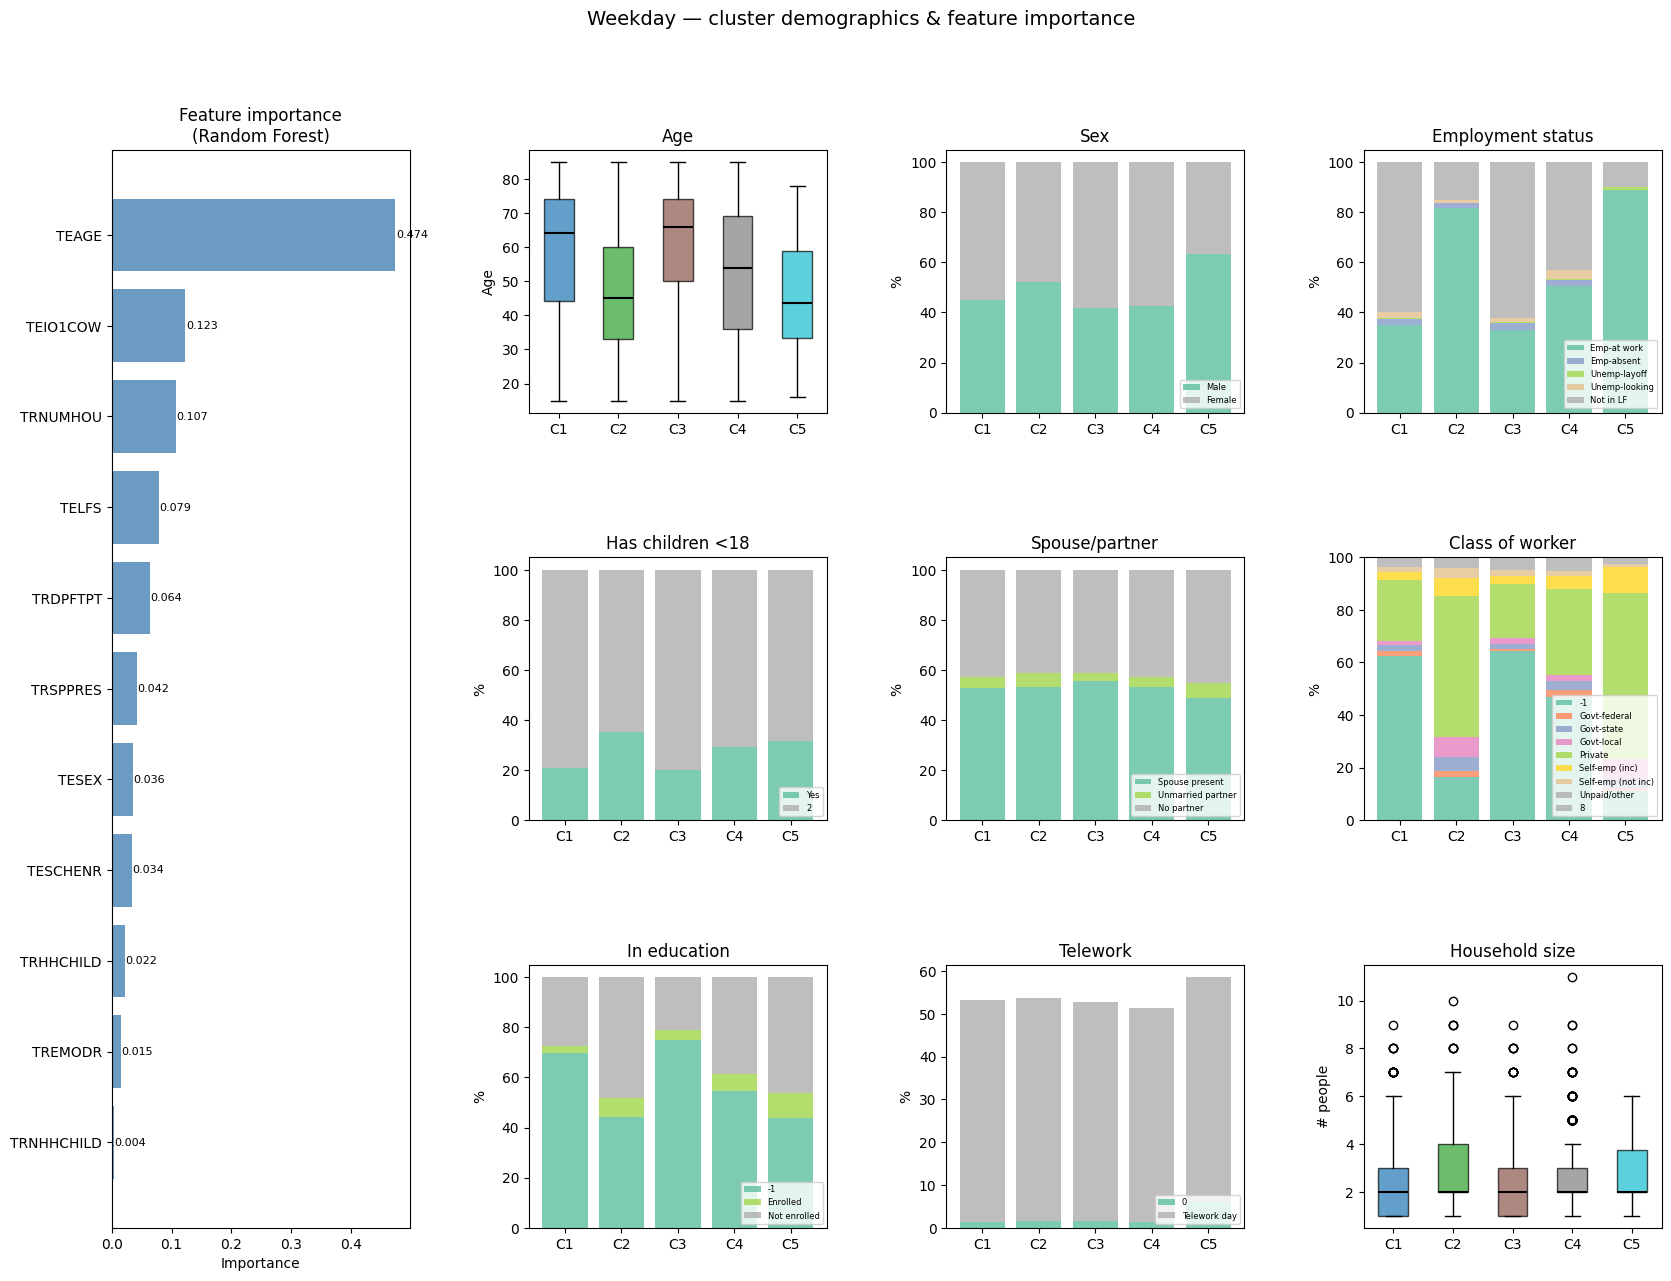

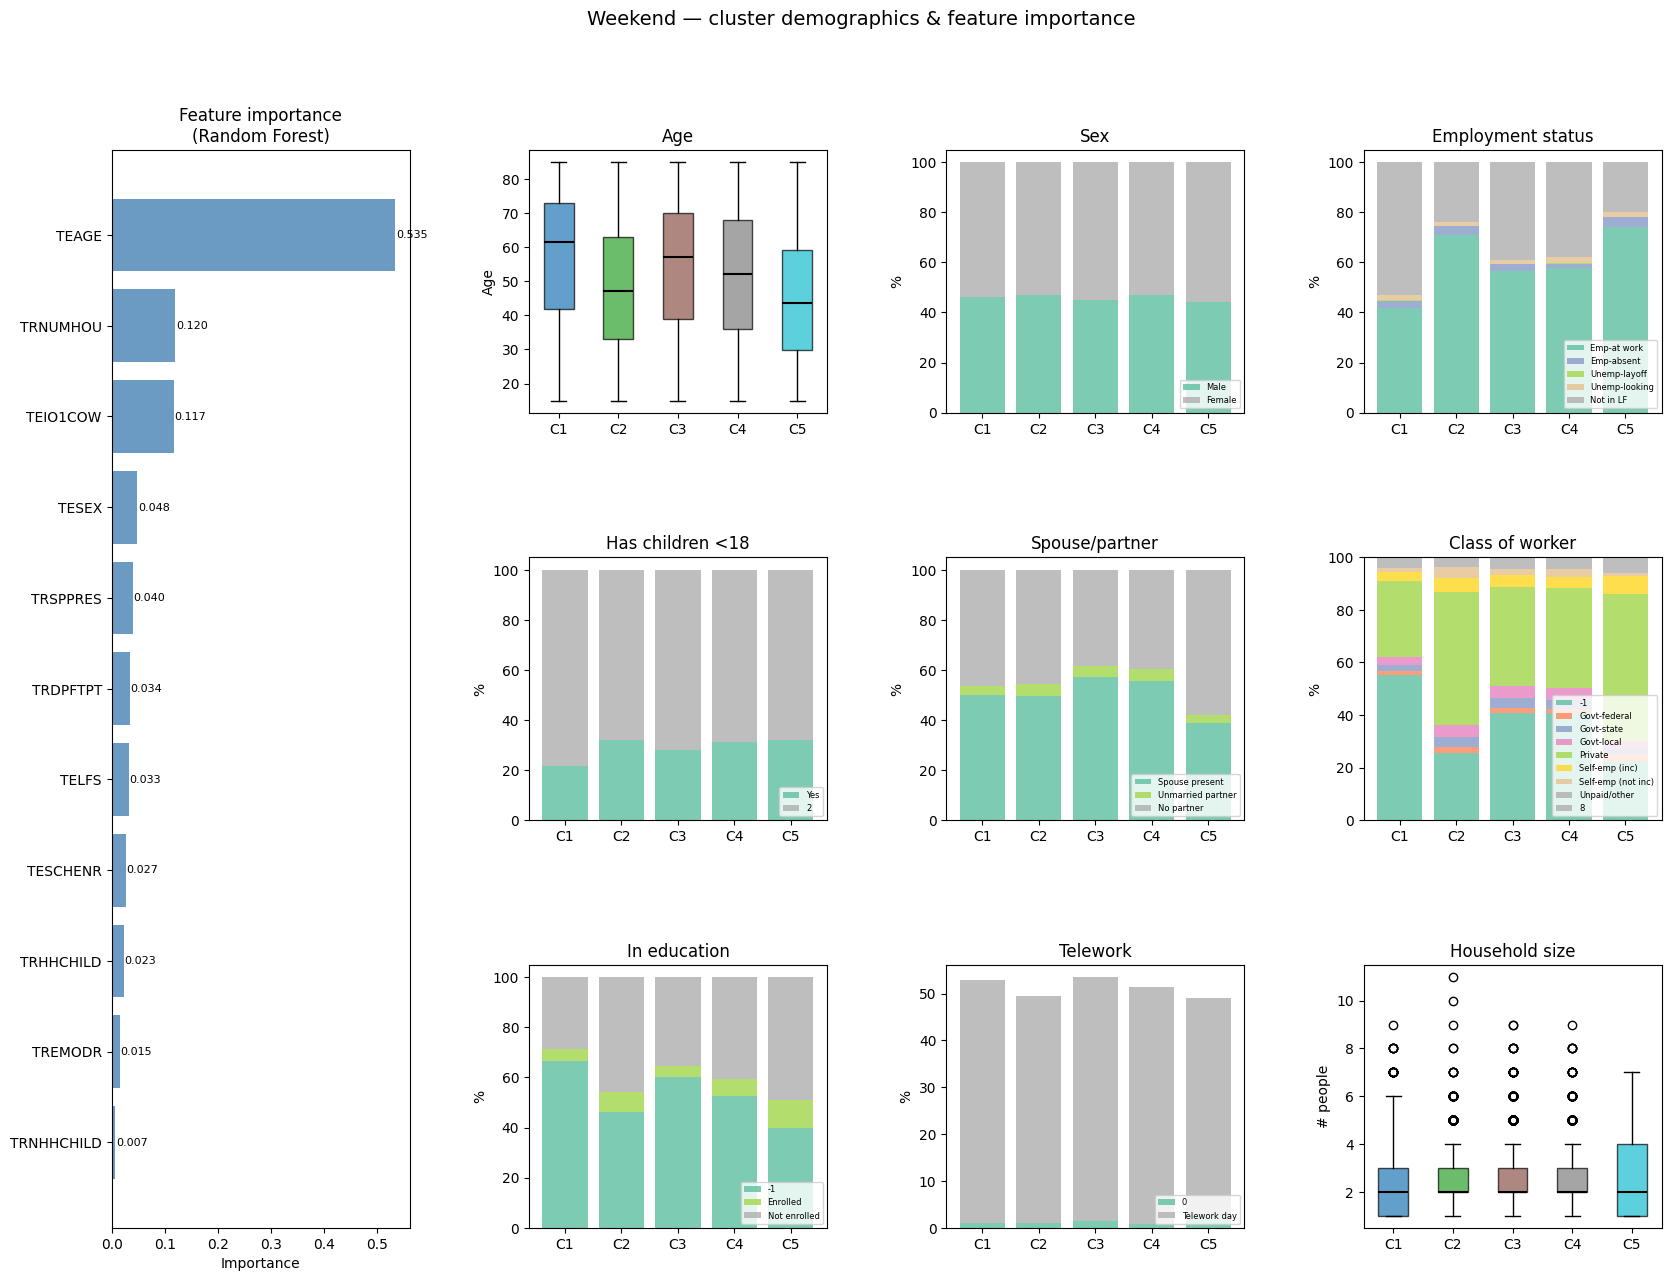

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

FEATURE_COLS = ['TEAGE', 'TESEX', 'TELFS', 'TESCHENR', 'TRDPFTPT',
                'TRHHCHILD', 'TRNHHCHILD', 'TRNUMHOU',
                'TRSPPRES', 'TEIO1COW', 'TREMODR']
FEATURE_COLS = [c for c in FEATURE_COLS if c in demo.columns]

def analyze_clusters(demo_df, daytype):
    df = demo_df[FEATURE_COLS + ['cluster']].dropna()
    X  = df[FEATURE_COLS].values
    y  = df['cluster'].values

    # --- Random forest feature importance ---
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

    k        = demo_df['cluster'].nunique()
    clusters = sorted(demo_df['cluster'].unique())
    c_colors = plt.cm.tab10(np.linspace(0, 1, k))

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'{daytype} — cluster demographics & feature importance', fontsize=14)
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

    # Feature importance (left column, full height)
    ax_imp = fig.add_subplot(gs[:, 0])
    bars = ax_imp.barh(importances.index, importances.values, color='steelblue', alpha=0.8)
    ax_imp.set_xlabel('Importance')
    ax_imp.set_title('Feature importance\n(Random Forest)')
    for bar, val in zip(bars, importances.values):
        ax_imp.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)

    def stacked_pct_bar(ax, col, title, val_map=None):
        vals = sorted(demo_df[col].dropna().unique())
        bottom = np.zeros(k)
        bar_colors = plt.cm.Set2(np.linspace(0, 1, len(vals)))
        for i, v in enumerate(vals):
            pcts = [(demo_df[demo_df['cluster'] == c][col] == v).sum() /
                    max((demo_df['cluster'] == c).sum(), 1) * 100
                    for c in clusters]
            lbl = val_map.get(int(v), str(int(v))) if val_map else str(int(v))
            ax.bar(range(k), pcts, bottom=bottom, label=lbl, color=bar_colors[i], alpha=0.85)
            bottom += np.array(pcts)
        ax.set_xticks(range(k)); ax.set_xticklabels([f'C{c+1}' for c in clusters])
        ax.set_ylabel('%'); ax.set_title(title)
        ax.legend(fontsize=6, loc='lower right', ncol=1)

    # Age boxplot
    ax = fig.add_subplot(gs[0, 1])
    bp = ax.boxplot([demo_df[demo_df['cluster'] == c]['TEAGE'].dropna() for c in clusters],
                    patch_artist=True, medianprops=dict(color='black', linewidth=1.5))
    for patch, col in zip(bp['boxes'], c_colors):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.set_xticks(range(1, k+1)); ax.set_xticklabels([f'C{c+1}' for c in clusters])
    ax.set_title('Age'); ax.set_ylabel('Age')

    # Sex
    ax = fig.add_subplot(gs[0, 2])
    stacked_pct_bar(ax, 'TESEX', 'Sex', {1: 'Male', 2: 'Female'})

    # Employment
    ax = fig.add_subplot(gs[0, 3])
    stacked_pct_bar(ax, 'TELFS', 'Employment status', telfs_map)

    # Has children
    ax = fig.add_subplot(gs[1, 1])
    stacked_pct_bar(ax, 'TRHHCHILD', 'Has children <18', {0: 'No', 1: 'Yes'})

    # Spouse/partner
    ax = fig.add_subplot(gs[1, 2])
    stacked_pct_bar(ax, 'TRSPPRES', 'Spouse/partner', sspresmap)

    # Class of worker
    if 'TEIO1COW' in demo_df.columns:
        ax = fig.add_subplot(gs[1, 3])
        stacked_pct_bar(ax, 'TEIO1COW', 'Class of worker', cowmap)

    # In school
    ax = fig.add_subplot(gs[2, 1])
    stacked_pct_bar(ax, 'TESCHENR', 'In education', {1: 'Enrolled', 2: 'Not enrolled'})

    # Remote work
    if 'TREMODR' in demo_df.columns:
        ax = fig.add_subplot(gs[2, 2])
        stacked_pct_bar(ax, 'TREMODR', 'Telework', remotemap)

    # Household size boxplot
    ax = fig.add_subplot(gs[2, 3])
    bp2 = ax.boxplot([demo_df[demo_df['cluster'] == c]['TRNUMHOU'].dropna() for c in clusters],
                     patch_artist=True, medianprops=dict(color='black', linewidth=1.5))
    for patch, col in zip(bp2['boxes'], c_colors):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.set_xticks(range(1, k+1)); ax.set_xticklabels([f'C{c+1}' for c in clusters])
    ax.set_title('Household size'); ax.set_ylabel('# people')

    plt.show()

analyze_clusters(demo_wd, 'Weekday')
analyze_clusters(demo_we, 'Weekend')


## Age Bucket Selection

Compare candidate 5- and 6-bucket schemes by Cramér's V (how much the binning preserves cluster separability).
Higher V = more cluster contrast retained.

**Selected: 6B — merge 25-44** → bins `[15, 25, 45, 55, 65, 75, 90]`, labels `['15-24', '25-44', '45-54', '55-64', '65-74', '75+']`

In [ ]:
# ── Build cluster_meta and reconcile labels for Markov-chain section ─────────
# Use the 5-group semantic labels (from the clustering above) as cluster IDs.
labels2_wd = labels_sem15_wd   # semantic labels 0-4 for weekday respondents
labels2_we = labels_sem15_we   # semantic labels 0-4 for weekend respondents

# Clusters 0-4 are already in semantic order (Mostly Home → Evening/Night Away).
_sem_order = np.arange(len(SEMANTIC_NAMES))  # [0, 1, 2, 3, 4]

cluster_meta = {
    'wd': {
        'order':     _sem_order,
        'rank_map':  {int(c): int(c) + 1 for c in _sem_order},  # 0->1, 1->2, ...
        'color_map': sem_cmap,
    },
    'we': {
        'order':     _sem_order,
        'rank_map':  {int(c): int(c) + 1 for c in _sem_order},
        'color_map': sem_cmap,
    },
}

print("cluster_meta defined — clusters:", list(_sem_order))
print("rank_map:", cluster_meta["wd"]["rank_map"])


cluster_meta defined — clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
rank_map: {0: 1, 1: 2, 2: 3, 3: 4, 4: 5}


In [80]:
from scipy.stats import chi2_contingency

# ── Candidate binning schemes ─────────────────────────────────────────────────
# Each entry: (label, bin_edges, bin_names)
SCHEMES = {
    '5A — merge working-age (25-54)':
        ([15, 25, 55, 65, 75, 100], ['15-24', '25-54', '55-64', '65-74', '75+']),
    '5B — merge middle (35-64)':
        ([15, 25, 35, 65, 75, 100], ['15-24', '25-34', '35-64', '65-74', '75+']),
    '5C — merge young (15-34) & retire (65+)':
        ([15, 35, 45, 55, 65, 100], ['15-34', '35-44', '45-54', '55-64', '65+']),
    '5D — natural life stages':
        ([15, 25, 45, 65, 75, 100], ['15-24', '25-44', '45-64', '65-74', '75+']),
    '5E — college/early working cut at 18':
        ([15, 18, 25, 65, 75, 100], ['15-17', '18-24', '25-64', '65-74', '75+']),
    '5F — college/early working, finer mid-career':
        ([15, 18, 25, 45, 65, 100], ['15-17', '18-24', '25-44', '45-64', '65+']),
    '5G — college/early working, late-career split':
        ([15, 18, 30, 55, 70, 100], ['15-17', '18-29', '30-54', '55-69', '70+']),
    '5H — college grad cut at 22':
        ([15, 22, 35, 55, 65, 100], ['15-21', '22-34', '35-54', '55-64', '65+']),
    '5I — teen + college years (18-21) distinct':
        ([15, 18, 22, 45, 65, 100], ['15-17', '18-21', '22-44', '45-64', '65+']),
    '5J — even 15-yr bands with 18 anchor':
        ([15, 18, 30, 45, 60, 100], ['15-17', '18-29', '30-44', '45-59', '60+']),
    '5K — pre-retiree (55-69) as own group':
        ([15, 25, 45, 55, 70, 100], ['15-24', '25-44', '45-54', '55-69', '70+']),
}

def scheme_cramer_v(demo_df, bins, labels):
    df = demo_df[['cluster', 'TEAGE']].dropna().copy()
    df['age_grp'] = pd.cut(df['TEAGE'], bins=bins, labels=labels, right=False)
    df = df.dropna(subset=['age_grp'])
    ct = pd.crosstab(df['cluster'], df['age_grp'])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return 0.0
    chi2 = chi2_contingency(ct, correction=False)[0]
    n    = ct.values.sum()
    k, r = ct.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

# Score each scheme for weekday and weekend
rows = []
for name, (bins, labels) in SCHEMES.items():
    v_wd = scheme_cramer_v(demo_wd, bins, labels)
    v_we = scheme_cramer_v(demo_we, bins, labels)
    rows.append({'Scheme': name, 'Buckets': len(labels),
                 "Cramér's V (WD)": v_wd, "Cramér's V (WE)": v_we,
                 "Mean V": (v_wd + v_we) / 2})

score_df = pd.DataFrame(rows).sort_values("Mean V", ascending=False)
print(score_df.to_string(index=False))
best_name = score_df.iloc[0]['Scheme']
print(f"\n  Best scheme: {best_name}")

# ── Visual comparison: top schemes side by side ───────────────────────────────
TOP_N = 4
top_schemes = score_df.head(TOP_N)['Scheme'].tolist()

def plot_age_heatmap(demo_df, bins, labels, tag, ax, title):
    """Heatmap: rows=clusters (display order), cols=age bins — % within cluster."""
    meta  = cluster_meta[tag]
    order = meta['order']
    rank_map = meta['rank_map']

    df = demo_df[['cluster', 'TEAGE']].dropna().copy()
    df['age_grp'] = pd.cut(df['TEAGE'], bins=bins, labels=labels, right=False)
    df = df.dropna(subset=['age_grp'])

    # % within cluster
    mat = pd.crosstab(df['cluster'], df['age_grp'])
    mat = mat.reindex(order)
    mat_pct = mat.div(mat.sum(axis=1), axis=0) * 100

    im = ax.imshow(mat_pct.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=60)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([f'C{rank_map[c]}' for c in order], fontsize=8)
    for lbl, c in zip(ax.get_yticklabels(), order):
        lbl.set_color(meta['color_map'][c])
    for i in range(mat_pct.shape[0]):
        for j in range(mat_pct.shape[1]):
            v = mat_pct.values[i, j]
            ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                    fontsize=7, color='white' if v > 35 else 'black')
    ax.set_title(title, fontsize=8)

fig, axes = plt.subplots(TOP_N, 2, figsize=(14, TOP_N * 3.2))
fig.suptitle('Age bucket schemes — % of cluster in each age group\n(higher contrast = better separation)', fontsize=12)

for row_i, sname in enumerate(top_schemes):
    bins, labels = SCHEMES[sname]
    v_wd = score_df[score_df['Scheme'] == sname]["Cramér's V (WD)"].values[0]
    v_we = score_df[score_df['Scheme'] == sname]["Cramér's V (WE)"].values[0]
    plot_age_heatmap(demo_wd, bins, labels, 'wd', axes[row_i, 0],
                     f'WD  V={v_wd:.3f}  |  {sname}')
    plot_age_heatmap(demo_we, bins, labels, 'we', axes[row_i, 1],
                     f'WE  V={v_we:.3f}')

plt.tight_layout()
plt.show()

NameError: name 'demo_wd' is not defined

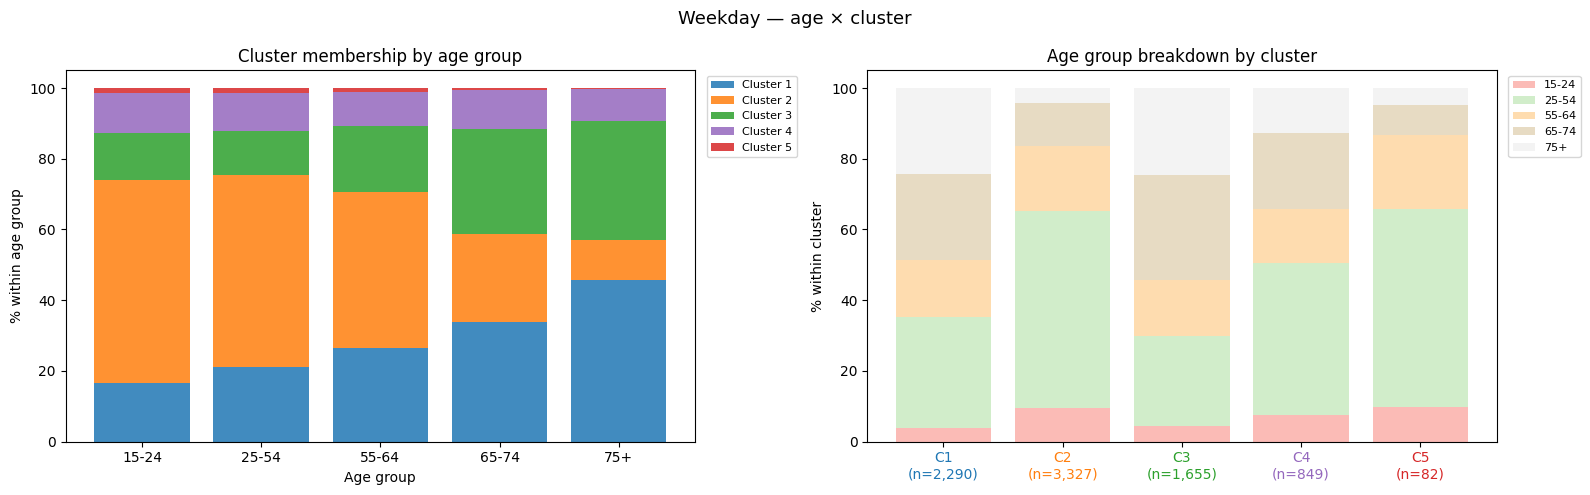

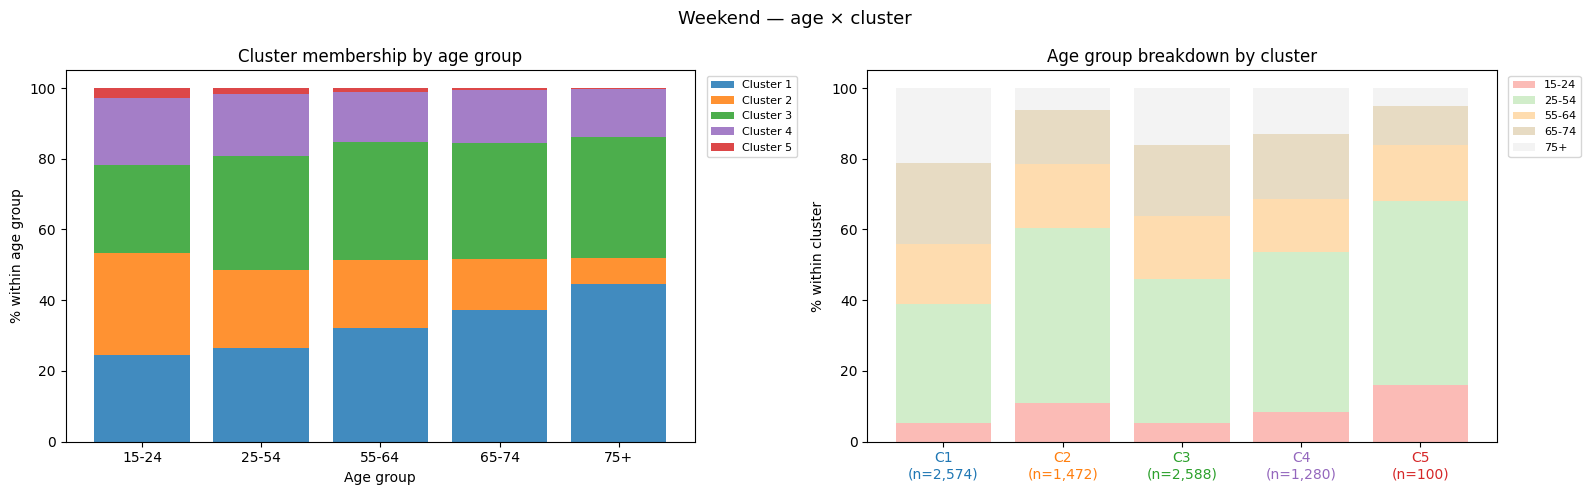

In [ ]:
# ── Best scheme from Cramér's V: 6B — merge 25-44 ────────────────────────────
AGE_BINS   = [15, 25, 55, 65, 75, 100]
AGE_LABELS = ['15-24', '25-54', '55-64', '65-74', '75+']

def plot_age_cluster(demo_df, daytype, tag):
    df = demo_df[['cluster', 'TEAGE']].dropna().copy()
    df['age_group'] = pd.cut(df['TEAGE'], bins=AGE_BINS, labels=AGE_LABELS, right=False)

    meta      = cluster_meta[tag]
    color_map = meta['color_map']
    rank_map  = meta['rank_map']
    order     = meta['order']           # raw cluster indices in display order
    clusters  = list(order)
    k         = len(clusters)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{daytype} — age × cluster', fontsize=13)

    # Panel 1: within each age group, % in each cluster (display order)
    ax = axes[0]
    age_cluster     = df.groupby(['age_group', 'cluster'], observed=True).size().unstack(fill_value=0)
    age_cluster_pct = age_cluster.div(age_cluster.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(AGE_LABELS))
    for c in clusters:
        if c not in age_cluster_pct.columns:
            continue
        vals = [age_cluster_pct.loc[a, c] if a in age_cluster_pct.index else 0 for a in AGE_LABELS]
        ax.bar(AGE_LABELS, vals, bottom=bottom,
               color=color_map[c], label=f'Cluster {rank_map[c]}', alpha=0.85)
        bottom += np.array(vals)
    ax.set_xlabel('Age group'); ax.set_ylabel('% within age group')
    ax.set_title('Cluster membership by age group')
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

    # Panel 2: within each cluster, age group breakdown (x-axis in display order)
    ax = axes[1]
    grp_colors = plt.cm.Pastel1(np.linspace(0, 1, len(AGE_LABELS)))
    bottom = np.zeros(k)
    for j, ag in enumerate(AGE_LABELS):
        vals = [(df[df['cluster'] == c]['age_group'] == ag).sum() /
                max((df['cluster'] == c).sum(), 1) * 100
                for c in clusters]
        ax.bar(range(k), vals, bottom=bottom, color=grp_colors[j], label=ag, alpha=0.9)
        bottom += np.array(vals)
    # Color x-tick labels to match centroid plot
    ax.set_xticks(range(k))
    xticklabels = ax.set_xticklabels(
        [f'C{rank_map[c]}\n(n={( demo_df["cluster"]==c).sum():,})' for c in clusters])
    for lbl, c in zip(xticklabels, clusters):
        lbl.set_color(color_map[c])
    ax.set_ylabel('% within cluster')
    ax.set_title('Age group breakdown by cluster')
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_age_cluster(demo_wd, 'Weekday', 'wd')
plot_age_cluster(demo_we, 'Weekend', 'we')

## Time-Inhomogeneous Markov Chain (3 States: sleep / home / away)

### State Space

$$\mathcal{S} = \{0,\, 1,\, 2\} \quad \text{(sleep, home/awake, away)}$$

Each respondent's diary day is discretized into $T = 96$ bins of 15 minutes,
indexed $t = 0, 1, \dots, T-1$, starting at 04:00.

### Occupancy Process

For cluster $c$ and day type $d$ (weekday / weekend), the occupancy sequence
$\{X_t\}_{t=0}^{T-1}$ is modeled as a **time-inhomogeneous Markov chain**:

$$P(X_{t+1} = j \mid X_t = i,\, X_{t-1},\, \dots) = P(X_{t+1} = j \mid X_t = i) = P^{(t)}_{ij}$$

where $P^{(t)} \in \mathbb{R}^{3 \times 3}$ is a row-stochastic transition matrix specific to time bin $t$:

$$P^{(t)}_{ij} \geq 0, \qquad \sum_{j \in \mathcal{S}} P^{(t)}_{ij} = 1 \quad \forall\, i \in \mathcal{S}$$

### Initial Distribution

The initial state distribution at $t = 0$ (04:00) is estimated per cluster as a weighted empirical proportion:

$$\pi^{(c)}_s = \frac{\displaystyle\sum_{k \in \mathcal{C}_c} w_k \,\mathbf{1}[X^{(k)}_0 = s]}{\displaystyle\sum_{k \in \mathcal{C}_c} w_k}, \qquad s \in \mathcal{S}$$

where $w_k$ is the ATUS person-level survey weight (`TUFINLWGT`) and $\mathcal{C}_c$ is the set of respondents in cluster $c$.

### Transition Matrix Estimation

Each $P^{(t)}$ is estimated from weighted empirical transition counts:

$$\hat{P}^{(t)}_{ij} = \frac{\displaystyle\sum_{k \in \mathcal{C}_c} w_k\, \mathbf{1}\bigl[X^{(k)}_t = i,\; X^{(k)}_{t+1} = j\bigr]}{\displaystyle\sum_{k \in \mathcal{C}_c} w_k\, \mathbf{1}\bigl[X^{(k)}_t = i\bigr]}$$

If the denominator is zero (state $i$ never observed at time $t$ in cluster $c$), the row is set to the uniform distribution.

In [12]:
# ── Build 3-state coarse vectors ─────────────────────────────────────────────
STATE_MAP_3 = {'sleep': 0, 'home': 1, 'away': 2}
N_STATES    = 3
STATE_NAMES = ['Sleep', 'Home', 'Away']
BIN_SIZE = 15
N_BINS = DIARY_LEN // BIN_SIZE

def episodes_to_vector_3state(episodes):
    vec = np.full(DIARY_LEN, -1, dtype=np.int8)
    for _, row in episodes.iterrows():
        start = int(np.clip(row['start_min'], 0, DIARY_LEN))
        stop  = int(np.clip(row['stop_min'],  0, DIARY_LEN))
        vec[start:stop] = STATE_MAP_3[row['state']]
    return vec

def coarsen_vector_3state(vec):
    coarse = np.full(N_BINS, -1, dtype=np.int8)
    for i in range(N_BINS):
        window   = vec[i * BIN_SIZE : (i + 1) * BIN_SIZE]
        recorded = window[window >= 0]
        if len(recorded) > 0:
            coarse[i] = np.bincount(recorded.astype(np.intp), minlength=N_STATES).argmax()
    return coarse

def ffill_int8(arr):
    """Forward-fill then back-fill -1 gaps."""
    out = arr.astype(float)
    out[out < 0] = np.nan
    mask = ~np.isnan(out)
    if mask.sum() == 0:
        return arr
    idx = np.where(mask, np.arange(len(out)), 0)
    np.maximum.accumulate(idx, out=idx)
    out = out[idx]
    if np.isnan(out[0]):
        out[np.isnan(out)] = out[mask][0]
    return out.astype(np.int8)

records3 = []
for (caseid, daytype), grp in state_episodes.groupby(['TUCASEID', 'daytype']):
    vec    = episodes_to_vector_3state(grp)
    coarse = coarsen_vector_3state(vec)
    coarse = ffill_int8(coarse)
    records3.append({'TUCASEID': caseid, 'daytype': daytype, 'vec': coarse})

state_vectors_3 = pd.DataFrame(records3)
print(f'3-state vectors: {state_vectors_3.shape}')
state_vectors_3.head(2)

3-state vectors: (16217, 3)


,TUCASEID,daytype,vec
0,20230101230035,weekday,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,20230101230077,weekend,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [16]:
# ── Build cluster_meta and reconcile labels for Markov-chain section ─────────
# Use the 5-group semantic labels (from the clustering above) as cluster IDs.
labels2_wd = labels_sem15_wd   # semantic labels 0-4 for weekday respondents
labels2_we = labels_sem15_we   # semantic labels 0-4 for weekend respondents

# Clusters 0-4 are already in semantic order (Mostly Home → Evening/Night Away).
_sem_order = np.arange(len(SEMANTIC_NAMES))  # [0, 1, 2, 3, 4]

cluster_meta = {
    'wd': {
        'order':     _sem_order,
        'rank_map':  {int(c): int(c) + 1 for c in _sem_order},  # 0->1, 1->2, ...
        'color_map': sem_cmap,
    },
    'we': {
        'order':     _sem_order,
        'rank_map':  {int(c): int(c) + 1 for c in _sem_order},
        'color_map': sem_cmap,
    },
}

print("cluster_meta defined — clusters:", list(_sem_order))
print("rank_map:", cluster_meta["wd"]["rank_map"])

# ── Attach cluster labels from existing clustering ────────────────────────────
# ids_wd / ids_we are the case IDs used in clustering; labels2_wd/we are the cluster assignments
cluster_map_wd = pd.Series(labels2_wd, index=ids_wd, name='cluster')
cluster_map_we = pd.Series(labels2_we, index=ids_we, name='cluster')

sv3_wd = (state_vectors_3[state_vectors_3['daytype'] == 'weekday']
          .join(cluster_map_wd, on='TUCASEID').dropna(subset=['cluster']))
sv3_we = (state_vectors_3[state_vectors_3['daytype'] == 'weekend']
          .join(cluster_map_we, on='TUCASEID').dropna(subset=['cluster']))

sv3_wd['cluster'] = sv3_wd['cluster'].astype(int)
sv3_we['cluster'] = sv3_we['cluster'].astype(int)

print(f'Weekday: {sv3_wd.shape}  clusters: {sorted(sv3_wd["cluster"].unique())}')
print(f'Weekend: {sv3_we.shape}  clusters: {sorted(sv3_we["cluster"].unique())}')

cluster_meta defined — clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
rank_map: {0: 1, 1: 2, 2: 3, 3: 4, 4: 5}
Weekday: (8203, 4)  clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Weekend: (8014, 4)  clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


Year-balance check (norm_total must be equal across years):
         raw_total  norm_total  n_resp  mean_w
year                                          
2023  9.903797e+10      8108.5    8548     0.9
2024  9.988597e+10      8108.5    7669     1.1


/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_63090/1879043713.py:105: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0,0),1,1, color=STATE_COLORS[s],  edgecolor='black', linewidth=0.8)


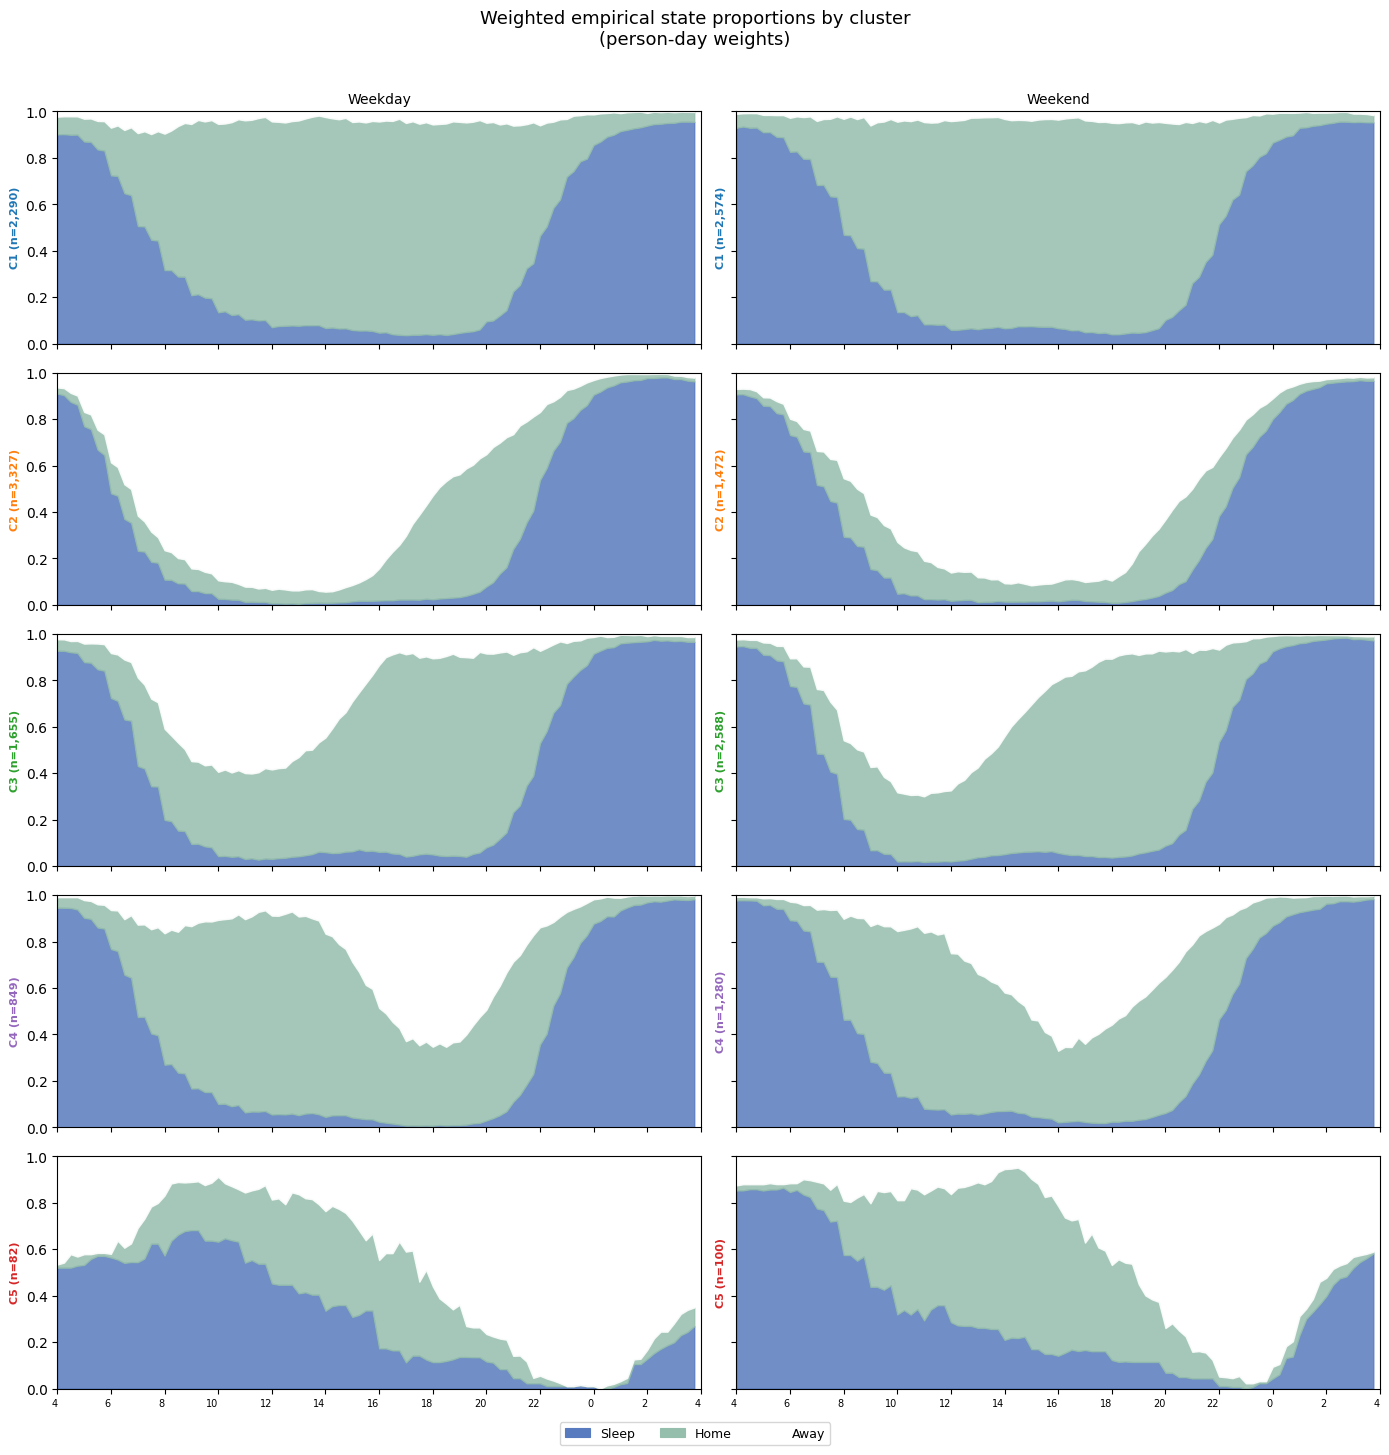

In [17]:
# ── Weighted empirical state proportions per cluster ──────────────────────────
# For each cluster × daytype × bin t:
#   P(state=s | t) = Σ w_i · 1[vec_i[t]=s]  /  Σ w_i
# where w_i = TUFINLWGT (person-level final weight).
STATE_COLORS = ['#587abe', "#96bead", '#ffffff']   # sleep / home / away

# Pull one weight per respondent; normalize per year so both years
# contribute equal total weight. Scale to N_total/2 per year so
# weights average ~1.0 and avoid tiny-fraction numerical issues.
wt_df     = (joined_data[['TUCASEID', 'TUFINLWGT', 'year']]
             .drop_duplicates('TUCASEID'))
N_total   = len(wt_df)
year_sums = wt_df.groupby('year')['TUFINLWGT'].transform('sum')
wt_df['weight_norm'] = wt_df['TUFINLWGT'] / year_sums * (N_total / 2)

# Sanity check: both years should now contribute equal total weight
_chk = wt_df.groupby('year').agg(
    raw_total =('TUFINLWGT',   'sum'),
    norm_total=('weight_norm', 'sum'),
    n_resp    =('TUCASEID',    'count'),
    mean_w    =('weight_norm', 'mean'),
)
print('Year-balance check (norm_total must be equal across years):')
print(_chk.round(1).to_string())
assert abs(_chk['norm_total'].diff().iloc[-1]) < 1e-6, 'Year weights not balanced!'

weights = wt_df.set_index('TUCASEID')['weight_norm']

# Attach weights to 3-state vectors
sv3_wd_w = sv3_wd.copy()
sv3_wd_w['weight'] = sv3_wd_w['TUCASEID'].map(weights).fillna(1.0)

sv3_we_w = sv3_we.copy()
sv3_we_w['weight'] = sv3_we_w['TUCASEID'].map(weights).fillna(1.0)

def weighted_state_props(sv_w, n_states=N_STATES):
    """
    Returns dict {cluster: ndarray (N_BINS, n_states)} of weighted proportions.
    """
    result = {}
    for c in sorted(sv_w['cluster'].unique()):
        grp     = sv_w[sv_w['cluster'] == c]
        vecs    = np.stack(grp['vec'].values)        # (n, N_BINS)
        w       = grp['weight'].values[:, np.newaxis] # (n, 1)
        props   = np.zeros((N_BINS, n_states))
        for s in range(n_states):
            num = (w * (vecs == s)).sum(axis=0)
            den = (w * (vecs >= 0)).sum(axis=0)      # exclude any remaining -1
            den[den == 0] = 1
            props[:, s] = num / den
        result[c] = props
    return result

props_wd = weighted_state_props(sv3_wd_w)
props_we = weighted_state_props(sv3_we_w)

# ── Plot: one row per cluster, weekday | weekend ──────────────────────────────
clusters_wd = sorted(props_wd.keys())
clusters_we = sorted(props_we.keys())
n_clusters  = max(len(clusters_wd), len(clusters_we))

xticks_  = np.arange(0, N_BINS + 1, 8)
xlabels_ = [f'{(4 + t * BIN_SIZE // 60) % 24}' for t in xticks_]

fig, axes = plt.subplots(n_clusters, 2,
                         figsize=(14, 2.8 * n_clusters),
                         sharex=True, sharey=True)
fig.suptitle('Weighted empirical state proportions by cluster\n(person-day weights)',
             fontsize=13, y=1.01)

for row_i in range(n_clusters):
    for col_i, (clusters, props, meta, daytype) in enumerate([
        (clusters_wd, props_wd, cluster_meta['wd'], 'Weekday'),
        (clusters_we, props_we, cluster_meta['we'], 'Weekend'),
    ]):
        ax = axes[row_i, col_i]
        if row_i >= len(clusters):
            ax.set_visible(False)
            continue

        c      = clusters[row_i]
        P      = props[c]                  # (N_BINS, 3)
        rank   = meta['rank_map'][c]
        color  = meta['color_map'][c]
        n_c    = (sv3_wd_w if col_i == 0 else sv3_we_w)['cluster'].eq(c).sum()

        bottom = np.zeros(N_BINS)
        for s in range(N_STATES):
            ax.fill_between(range(N_BINS), bottom, bottom + P[:, s],
                            color=STATE_COLORS[s], alpha=0.85,
                            label=STATE_NAMES[s] if row_i == 0 else '_')
            bottom += P[:, s]

        ax.set_ylim(0, 1)
        ax.set_xlim(0, N_BINS - 1)
        ax.set_ylabel(f'C{rank} (n={n_c:,})', fontsize=8,
                      color=color, fontweight='bold')
        if row_i == 0:
            ax.set_title(daytype, fontsize=10)
        if row_i == n_clusters - 1:
            ax.set_xticks(xticks_)
            ax.set_xticklabels(xlabels_, rotation=0, ha='right', fontsize=7)

# Shared legend at top
handles = [plt.Rectangle((0,0),1,1, color=STATE_COLORS[s],  edgecolor='black', linewidth=0.8)
           for s in range(N_STATES)]
fig.legend(handles, STATE_NAMES, loc='lower center', fontsize=9,
           bbox_to_anchor=(0.5,-0.02), ncol=3)

plt.tight_layout()
plt.show()

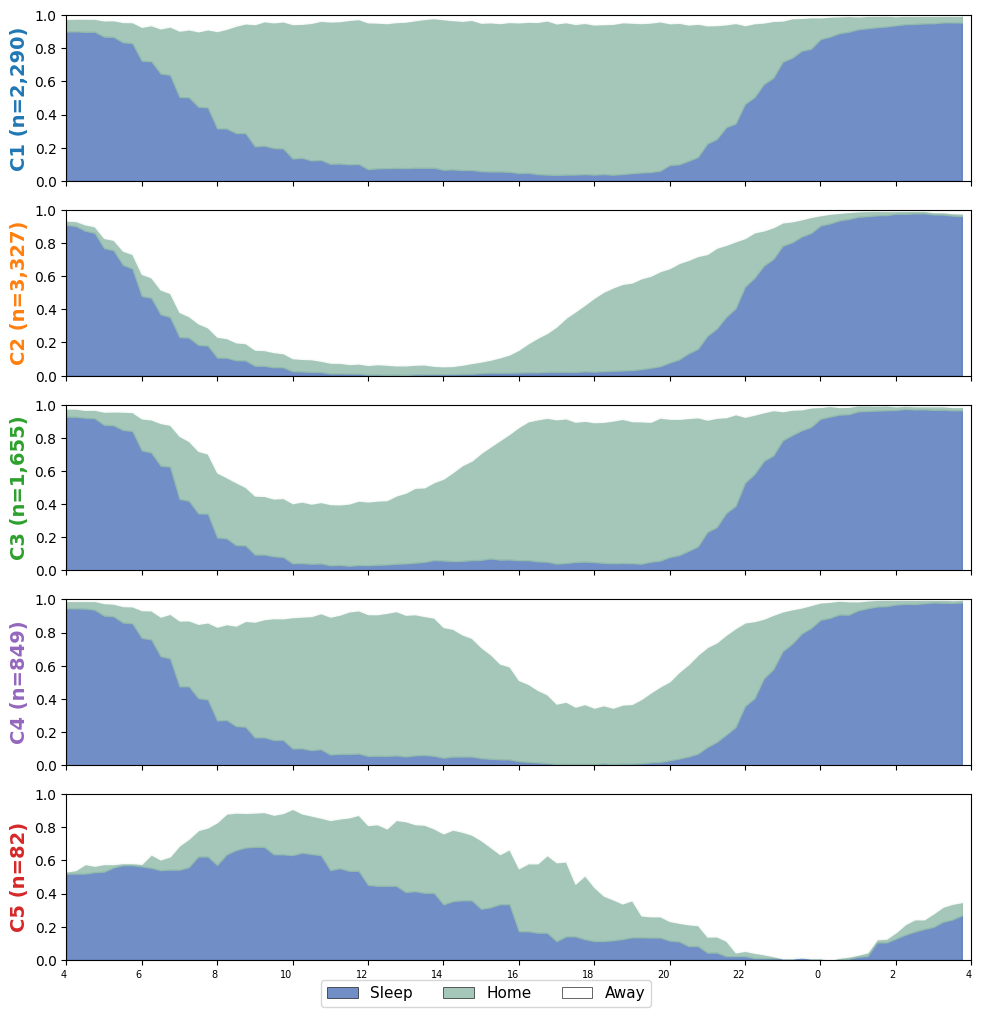

In [18]:
fig, axes = plt.subplots(n_clusters, 1,
                         figsize=(10, 2 * n_clusters),
                         sharex=True, sharey=True)
# fig.suptitle('Weighted empirical state proportions by cluster\n(person-day weights)',
#              fontsize=13, y=1.01)

for row_i, c in enumerate(clusters_wd):
    ax     = axes[row_i]
    P      = props_wd[c]
    rank   = cluster_meta['wd']['rank_map'][c]
    color  = cluster_meta['wd']['color_map'][c]
    n_c    = sv3_wd_w['cluster'].eq(c).sum()

    bottom = np.zeros(N_BINS)
    for s in range(N_STATES):
        ax.fill_between(range(N_BINS), bottom, bottom + P[:, s],
                        color=STATE_COLORS[s], alpha=0.85,
                        label=STATE_NAMES[s] if row_i == 0 else '_')
        bottom += P[:, s]

    ax.set_ylim(0, 1)
    ax.set_xlim(0, N_BINS - 1)
    ax.set_ylabel(f'C{rank} (n={n_c:,})', fontsize=14,
                  color=color, fontweight='bold')
    # if row_i == 0:
    #     ax.set_title('Weekday', fontsize=10)
    if row_i == n_clusters - 1:
        ax.set_xticks(xticks_)
        ax.set_xticklabels(xlabels_, rotation=0, ha='right', fontsize=7)

handles = [plt.Rectangle((0,0),1,1, facecolor=STATE_COLORS[s],  alpha=0.85, edgecolor='black', linewidth=0.5)
           for s in range(N_STATES)]
fig.legend(handles, STATE_NAMES, loc='lower center', fontsize=11,
           bbox_to_anchor=(0.5,-0.02), ncol=3)

plt.tight_layout()
plt.show()



In [19]:
# ── Compute weighted time-inhomogeneous transition matrices ───────────────────
# P^(t)_{i→j} = Σ w_k · 1[s_k(t)=i, s_k(t+1)=j]  /  Σ w_k · 1[s_k(t)=i]
def compute_transition_matrices(sv_w, n_states=N_STATES):
    clusters = sorted(sv_w['cluster'].unique())
    trans  = {}
    counts = {}

    for c in clusters:
        grp     = sv_w[sv_w['cluster'] == c]
        members = np.stack(grp['vec'].values)   # (n, N_BINS)
        w       = grp['weight'].values           # (n,)
        T = N_BINS                               # 96 transitions (including wrap-around)
        C = np.zeros((T, n_states, n_states), dtype=np.float64)

        for t in range(T):
            s_from = members[:, t]
            s_to   = members[:, (t + 1) % N_BINS]   # wraps: bin 95 → bin 0
            valid  = (s_from >= 0) & (s_to >= 0)
            for i in range(n_states):
                for j in range(n_states):
                    mask = valid & (s_from == i) & (s_to == j)
                    C[t, i, j] = w[mask].sum()

        row_sums  = C.sum(axis=2, keepdims=True)
        zero_rows = (row_sums[:, :, 0] == 0)
        row_sums[zero_rows] = 1
        P = C / row_sums
        P[zero_rows] = 1.0 / n_states

        trans[c]  = P
        counts[c] = C

    return trans, counts


trans_wd, counts_wd = compute_transition_matrices(sv3_wd_w)
trans_we, counts_we = compute_transition_matrices(sv3_we_w)

c0 = list(trans_wd.keys())[0]
assert np.allclose(trans_wd[c0].sum(axis=2), 1.0), "Row sums != 1"
print('Weighted transition matrices computed.')
print(f'  Shape per cluster: {trans_wd[c0].shape}  '
      f'→ {N_BINS-1} time steps × {N_STATES}×{N_STATES}')

for tag, counts_dict in [('Weekday', counts_wd), ('Weekend', counts_we)]:
    for c, C in counts_dict.items():
        zero = (C.sum(axis=2) == 0).sum()
        if zero > 0:
            print(f'  {tag} cluster {c}: {zero} (t, from-state) pairs had zero weight → uniform fallback')

Weighted transition matrices computed.
  Shape per cluster: (96, 3, 3)  → 95 time steps × 3×3
  Weekday cluster 4: 8 (t, from-state) pairs had zero weight → uniform fallback
  Weekend cluster 4: 1 (t, from-state) pairs had zero weight → uniform fallback


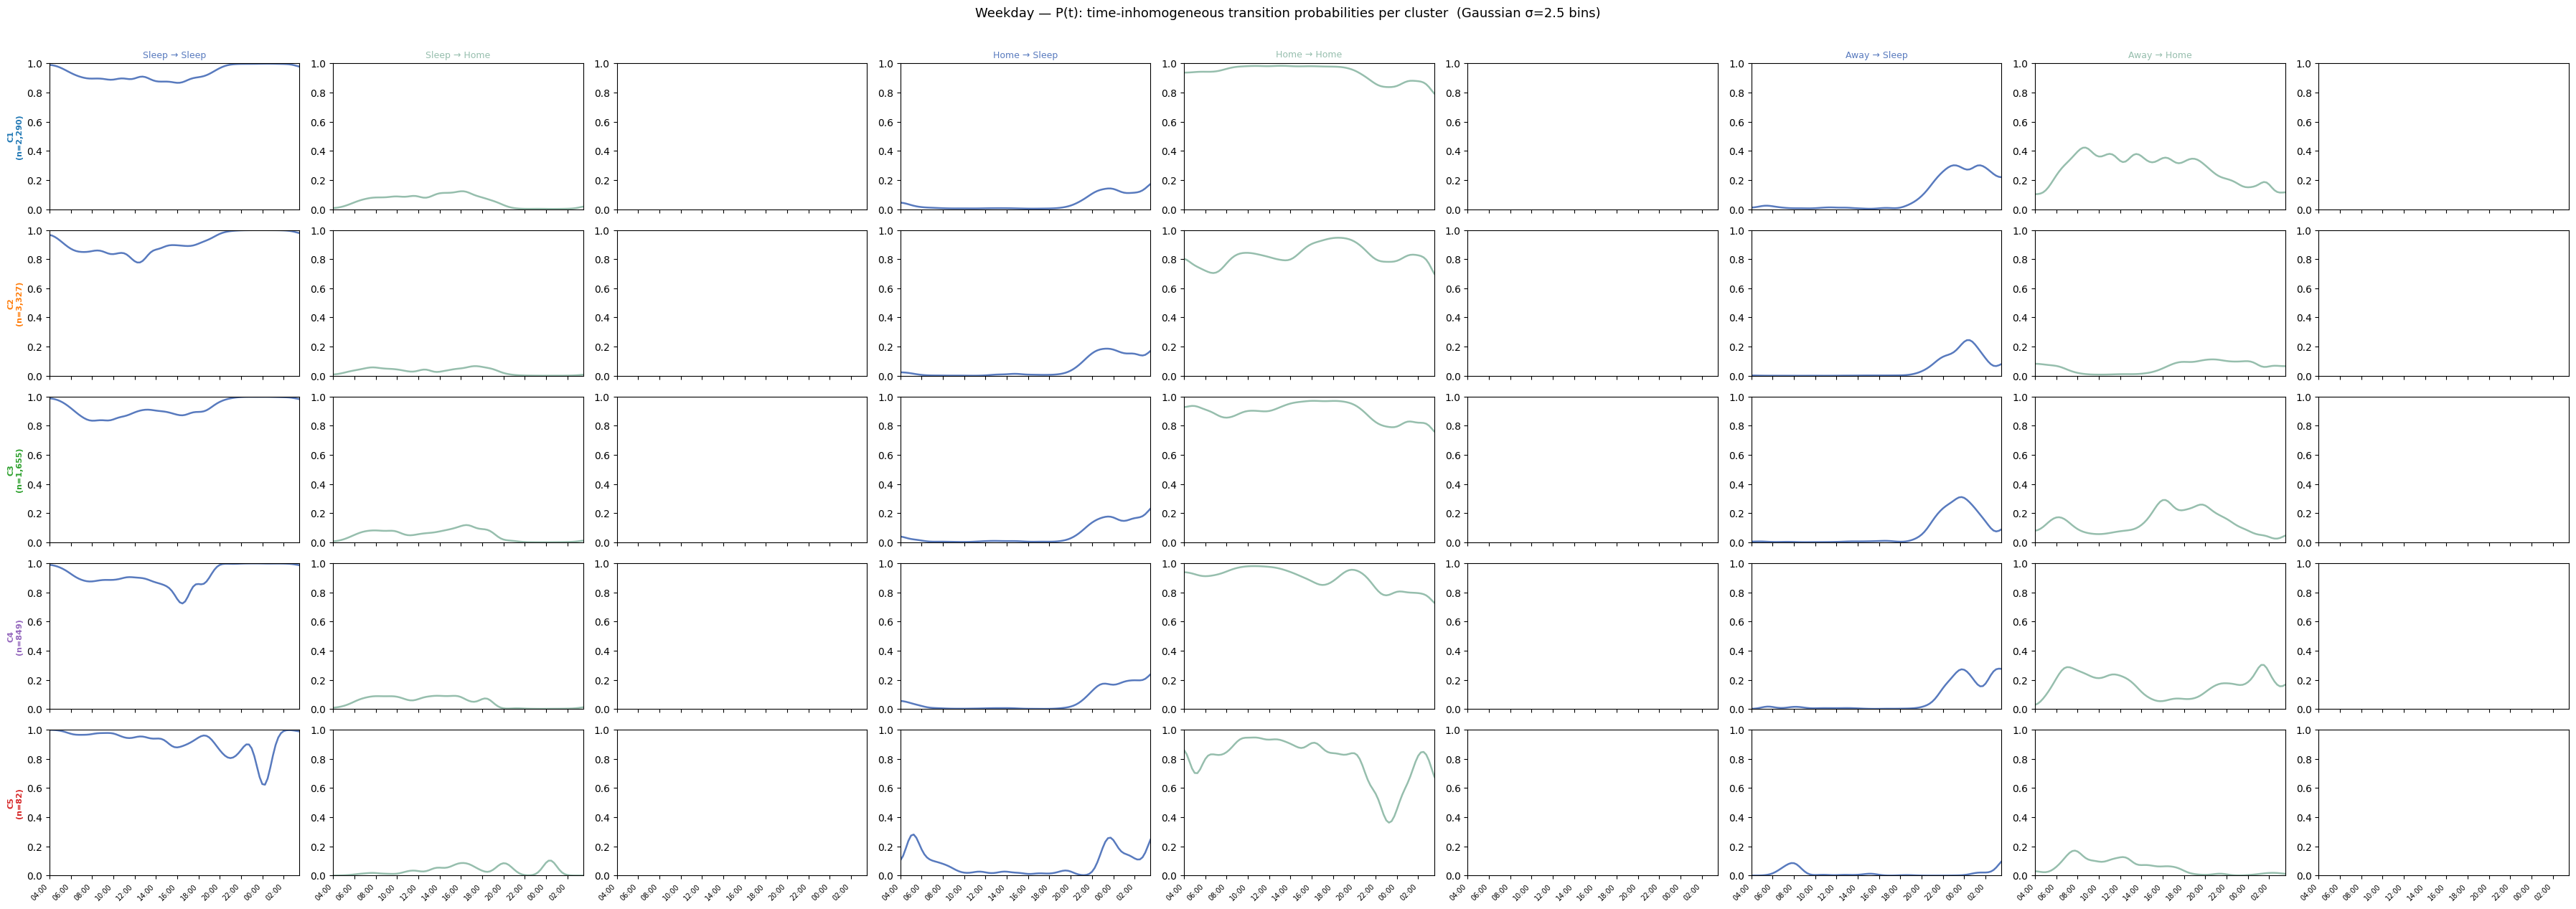

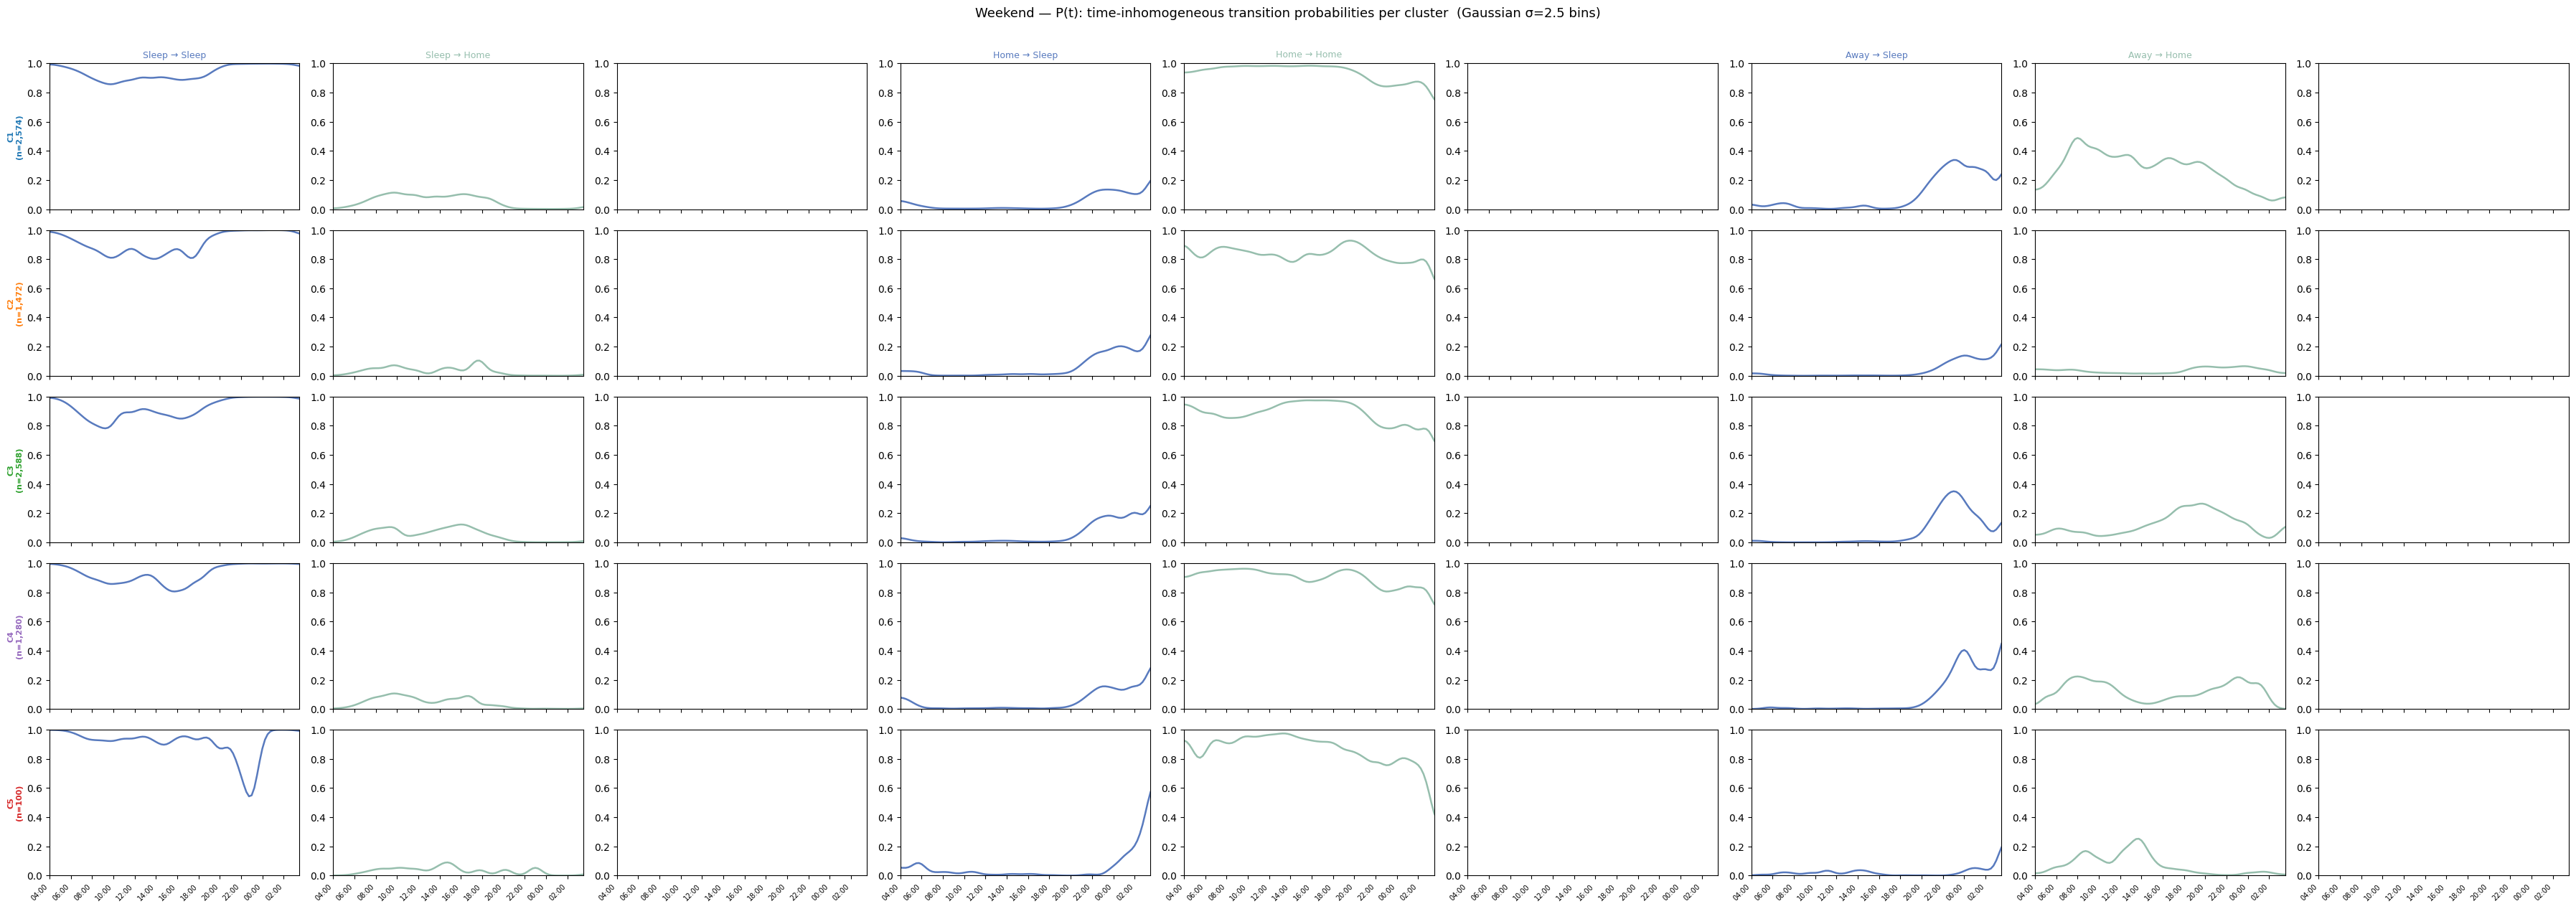

In [20]:
# ── Visualise transition matrices per cluster (smoothed) ─────────────────────
# Gaussian smoothing along the time axis to reduce bin-to-bin noise.
# Raw count matrices are preserved; smoothing is applied only for display.



SMOOTH_SIGMA = 2.5


xticks_  = np.arange(0, N_BINS, 8)
xlabels_ = [f'{(4 + t * BIN_SIZE // 60) % 24:02d}:00' for t in xticks_]
t_axis   = np.arange(N_BINS )

def smooth_trans(P, sigma=SMOOTH_SIGMA):
    """Gaussian-smooth each (i,j) curve along axis 0 (time), then re-normalise rows."""
    P_s = gaussian_filter1d(P, sigma=sigma, axis=0)
    row_sums = P_s.sum(axis=2, keepdims=True)
    row_sums[row_sums == 0] = 1
    return P_s / row_sums

def plot_trans_matrices(trans_dict, sv_df, meta, daytype):
    clusters = sorted(trans_dict.keys())
    k        = len(clusters)

    fig, axes = plt.subplots(k, N_STATES * N_STATES,
                             figsize=(4 * N_STATES * N_STATES, 2.5 * k),
                             sharex=True, sharey=False)
    fig.suptitle(f'{daytype} — P(t): time-inhomogeneous transition probabilities per cluster'
                 f'  (Gaussian σ={SMOOTH_SIGMA} bins)',
                 fontsize=13, y=1.01)

    for row_i, c in enumerate(clusters):
        P       = smooth_trans(trans_dict[c])    # (N_BINS-1, 3, 3)
        n_c     = (sv_df['cluster'] == c).sum()
        rank    = meta['rank_map'][c]
        c_color = meta['color_map'][c]

        for s_from in range(N_STATES):
            for s_to in range(N_STATES):
                col_i = s_from * N_STATES + s_to
                ax    = axes[row_i, col_i]

                ax.plot(t_axis, P[:, s_from, s_to],
                        color=STATE_COLORS[s_to], linewidth=1.8)
                ax.set_ylim(0, 1)
                ax.set_xlim(0, N_BINS - 2)

                if row_i == 0:
                    ax.set_title(f'{STATE_NAMES[s_from]} → {STATE_NAMES[s_to]}',
                                 fontsize=9, color=STATE_COLORS[s_to])
                if col_i == 0:
                    ax.set_ylabel(f'C{rank}\n(n={n_c:,})', fontsize=8,
                                  color=c_color, fontweight='bold')
                if row_i == k - 1:
                    ax.set_xticks(xticks_)
                    ax.set_xticklabels(xlabels_, rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.show()

plot_trans_matrices(trans_wd, sv3_wd, cluster_meta['wd'], 'Weekday')
plot_trans_matrices(trans_we, sv3_we, cluster_meta['we'], 'Weekend')

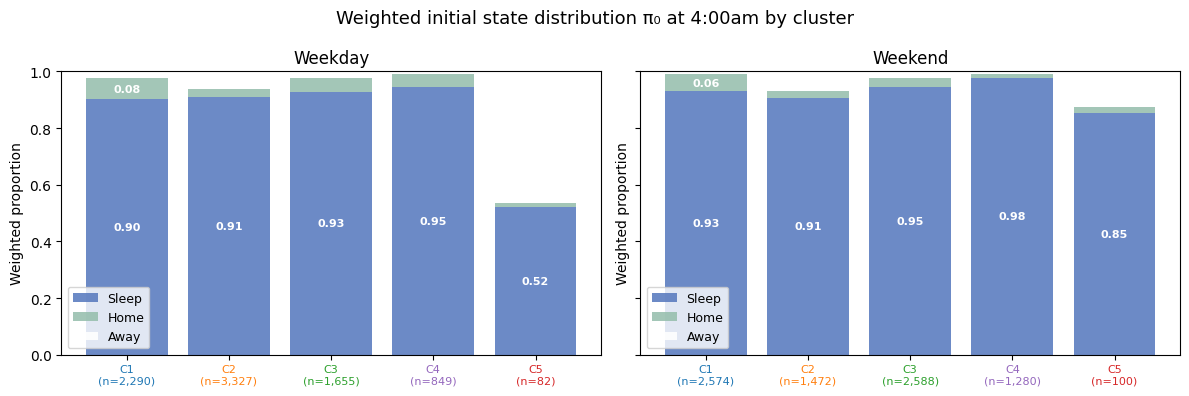


Weekday π₀ (weighted):
     Cluster     Sleep      Home      Away
  C1 (raw 0):    0.9008    0.0764    0.0228
  C2 (raw 1):    0.9093    0.0267    0.0640
  C3 (raw 2):    0.9275    0.0490    0.0235
  C4 (raw 3):    0.9456    0.0452    0.0092
  C5 (raw 4):    0.5205    0.0133    0.4662

Weekend π₀ (weighted):
     Cluster     Sleep      Home      Away
  C1 (raw 0):    0.9293    0.0601    0.0106
  C2 (raw 1):    0.9063    0.0233    0.0704
  C3 (raw 2):    0.9457    0.0296    0.0247
  C4 (raw 3):    0.9772    0.0151    0.0077
  C5 (raw 4):    0.8528    0.0216    0.1255


In [21]:
# ── Weighted initial state distribution π₀ per cluster ───────────────────────
# π₀[s] = Σ w_k · 1[state_k(0)=s]  /  Σ w_k

def compute_initial_distribution(sv_w, n_states=N_STATES):
    """Returns dict {cluster_id: ndarray (n_states,)} of weighted proportions."""
    result = {}
    for c in sorted(sv_w['cluster'].unique()):
        grp    = sv_w[sv_w['cluster'] == c]
        s0     = np.stack(grp['vec'].values)[:, 0]   # state at bin 0
        w      = grp['weight'].values
        valid  = s0 >= 0
        counts = np.array([w[valid & (s0 == s)].sum() for s in range(n_states)])
        result[c] = counts / counts.sum()
    return result

pi0_wd = compute_initial_distribution(sv3_wd_w)
pi0_we = compute_initial_distribution(sv3_we_w)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('Weighted initial state distribution π₀ at 4:00am by cluster', fontsize=13)

for ax, pi0, sv_w, meta, daytype in [
    (axes[0], pi0_wd, sv3_wd_w, cluster_meta['wd'], 'Weekday'),
    (axes[1], pi0_we, sv3_we_w, cluster_meta['we'], 'Weekend'),
]:
    clusters = sorted(pi0.keys())
    x        = np.arange(len(clusters))
    bottom   = np.zeros(len(clusters))

    for s in range(N_STATES):
        vals = [pi0[c][s] for c in clusters]
        ax.bar(x, vals, bottom=bottom, color=STATE_COLORS[s],
               label=STATE_NAMES[s], alpha=0.88)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.05:
                ax.text(i, b + v / 2, f'{v:.2f}', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += np.array(vals)

    rank_labels = [f'C{meta["rank_map"][c]}\n(n={( sv_w["cluster"]==c).sum():,})'
                   for c in clusters]
    ax.set_xticks(x)
    ax.set_xticklabels(rank_labels, fontsize=8)
    for lbl, c in zip(ax.get_xticklabels(), clusters):
        lbl.set_color(meta['color_map'][c])
    ax.set_ylabel('Weighted proportion')
    ax.set_ylim(0, 1)
    ax.set_title(daytype)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print table
for tag, pi0, meta in [('Weekday', pi0_wd, cluster_meta['wd']),
                        ('Weekend', pi0_we, cluster_meta['we'])]:
    print(f'\n{tag} π₀ (weighted):')
    print(f'  {"Cluster":>10}  ' + '  '.join(f'{s:>8}' for s in STATE_NAMES))
    for c in sorted(pi0.keys()):
        print(f'  C{meta["rank_map"][c]} (raw {c}):  ' +
              '  '.join(f'{v:>8.4f}' for v in pi0[c]))

## Simulation from the Markov Chain

Run the time-inhomogeneous MC for a full week (Mon–Sun).  
Each day uses its own set of transition matrices; the state at the end of one day seeds the next.  
The "typical day" is obtained by running many independent trajectories and averaging.

In [23]:
# ── Choose clusters to simulate ───────────────────────────────────────────────
# Pick the raw cluster index (key in trans_wd / trans_we).
# Largest cluster by default — change as desired.
SIM_CLUSTER = 1  # semantic clusters are 0-4; 0=Mostly Home


print(f'Simulating weekday cluster {SIM_CLUSTER} '
      f'(C{cluster_meta["wd"]["rank_map"][SIM_CLUSTER]}, '
      f'n={( sv3_wd["cluster"]==SIM_CLUSTER).sum():,})')
print(f'Simulating weekend cluster {SIM_CLUSTER} '
      f'(C{cluster_meta["we"]["rank_map"][SIM_CLUSTER]}, '
      f'n={( sv3_we["cluster"]==SIM_CLUSTER).sum():,})')

# Week layout starting Monday: 5 weekdays then 2 weekend days
WEEK_SCHEDULE = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
WEEK_TYPES    = ['wd', 'wd', 'wd', 'wd', 'wd', 'we', 'we']
N_DAYS        = len(WEEK_SCHEDULE)
N_STEPS_WEEK  = N_DAYS * N_BINS          # total 30-min bins in a week

def day_trans(daytype):
    """Return (trans_matrices, pi0, cluster) for the given daytype tag."""
    if daytype == 'wd':
        return trans_wd[SIM_CLUSTER], pi0_wd[SIM_CLUSTER]
    else:
        return trans_we[SIM_CLUSTER], pi0_we[SIM_CLUSTER]

def sample_state(probs, rng):
    return rng.choice(N_STATES, p=probs)

def simulate_week(rng, n_states=N_STATES):
    """
    Simulate one trajectory over a full week.
    Returns array of shape (N_STEPS_WEEK,) with state at each 15-min bin.
    """
    traj = np.empty(N_STEPS_WEEK, dtype=np.int8)

    # Initialise from Monday's π₀
    P0, pi0 = day_trans('wd')
    state   = sample_state(pi0, rng)

    for day_i, dtype in enumerate(WEEK_TYPES):
        P, _ = day_trans(dtype)          # (N_BINS, 3, 3)  ← now 96 transitions
        base  = day_i * N_BINS
        traj[base] = state
        for t in range(N_BINS - 1):
            state = sample_state(P[t, state], rng)
            traj[base + t + 1] = state
        # t=95: explicit 03:45→04:00 transition produces next day's bin-0 state
        state = sample_state(P[N_BINS - 1, state], rng)

    return traj


Simulating weekday cluster 1 (C2, n=3,327)
Simulating weekend cluster 1 (C2, n=1,472)


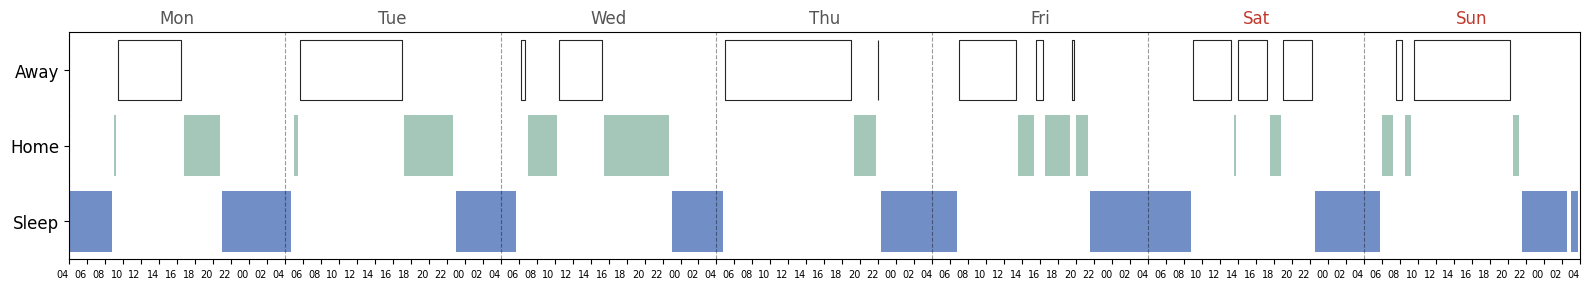

In [24]:
# ── Single-week trajectory plot ───────────────────────────────────────────────
rng       = np.random.default_rng(42)
one_week  = simulate_week(rng)

# Build time axis labels (4am = 0 for each day)
tick_days  = np.arange(0, N_STEPS_WEEK + 1, N_BINS)       # day boundaries
tick_hours = np.arange(0, N_STEPS_WEEK + 1, 8)            # every 4 h within week

fig, ax = plt.subplots(figsize=(16, 3))

# Colour-fill state bands
for s in range(N_STATES):
    mask = (one_week == s).astype(float)
    # Draw as filled steps
    ax.fill_between(range(N_STEPS_WEEK), s - 0.4, s + 0.4,
                    where=one_week == s,
                    facecolor=STATE_COLORS[s], alpha=0.85, step='post',
                    edgecolor='black' if s == 2 else 'none', linewidth=0.8)

ax.set_yticks(range(N_STATES))
ax.set_yticklabels(STATE_NAMES, fontsize =12)
ax.set_ylim(-0.5, N_STATES - 0.5)

# Day boundary lines + labels
for d, (name, dtype) in enumerate(zip(WEEK_SCHEDULE, WEEK_TYPES)):
    x = d * N_BINS
    ax.axvline(x, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.text(x + N_BINS / 2, N_STATES-0.2, name,
            ha='center', va='top', fontsize=12,
            color='#555' if dtype == 'wd' else '#c0392b')

ax.set_xticks(tick_hours)
ax.set_xticklabels(
    [f'{(4 + (t % N_BINS) * BIN_SIZE // 60) % 24:02d}' for t in tick_hours],
    rotation=0, ha='right', fontsize=7)
ax.set_xlim(0, N_STEPS_WEEK)
# ax.set_title('Single simulated week', fontsize=12)
plt.tight_layout()
plt.show()

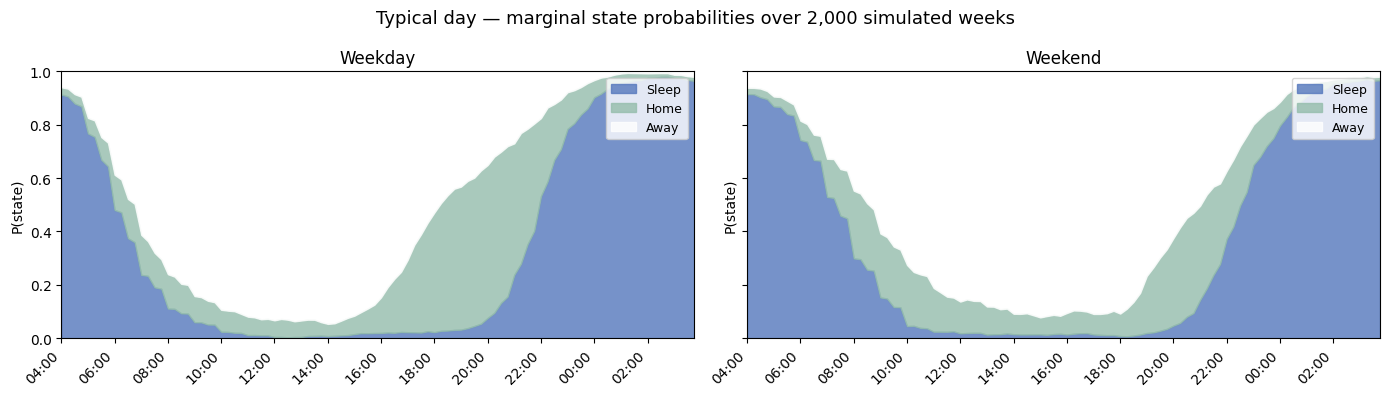

In [25]:
# ── Many runs → aggregate typical day ────────────────────────────────────────
N_SIM = 2000
rng   = np.random.default_rng(0)

all_weeks = np.stack([simulate_week(rng) for _ in range(N_SIM)])  # (N_SIM, N_STEPS_WEEK)

# Reshape to (N_SIM, N_DAYS, N_BINS) and compute per-daytype marginals
all_weeks_rs = all_weeks.reshape(N_SIM, N_DAYS, N_BINS)

# Separate weekday days (0-4) and weekend days (5-6)
wd_days = all_weeks_rs[:, :5, :].reshape(-1, N_BINS)   # (N_SIM*5, N_BINS)
we_days = all_weeks_rs[:, 5:, :].reshape(-1, N_BINS)   # (N_SIM*2, N_BINS)

def marginal_probs(day_matrix, n_states=N_STATES):
    """Fraction of simulations in each state at each bin. Shape: (N_BINS, n_states)."""
    n = day_matrix.shape[0]
    return np.stack([(day_matrix == s).mean(axis=0) for s in range(n_states)], axis=1)

prob_wd = marginal_probs(wd_days)   # (N_BINS, 3)
prob_we = marginal_probs(we_days)

# ── Plot typical day ──────────────────────────────────────────────────────────
xticks_  = np.arange(0, N_BINS + 1, 8)
xlabels_ = [f'{(4 + t * BIN_SIZE // 60) % 24:02d}:00' for t in xticks_]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle(f'Typical day — marginal state probabilities over {N_SIM:,} simulated weeks',
             fontsize=13)

for ax, prob, daytype in [(axes[0], prob_wd, 'Weekday'), (axes[1], prob_we, 'Weekend')]:
    bottom = np.zeros(N_BINS)
    for s in range(N_STATES):
        ax.fill_between(range(N_BINS), bottom, bottom + prob[:, s],
                        color=STATE_COLORS[s], alpha=0.82, label=STATE_NAMES[s])
        bottom += prob[:, s]
    ax.set_xticks(xticks_)
    ax.set_xticklabels(xlabels_, rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, N_BINS - 1)
    ax.set_ylabel('P(state)')
    ax.set_title(daytype)
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

In [26]:
# ── Save π₀ and transition matrices ordered by cluster rank ──────────────────
import os

OUT_DIR = '/Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability'
os.makedirs(OUT_DIR, exist_ok=True)

# ── 1. Initial distributions — one CSV per daytype ───────────────────────────
# Rows ordered by rank (1 → k), columns = state names
for daytype, pi0, meta in [('weekday', pi0_wd, cluster_meta['wd']),
                             ('weekend', pi0_we, cluster_meta['we'])]:
    rows = []
    subdir = os.path.join(OUT_DIR, daytype)
    for rank, raw in enumerate(meta['order']):
        rows.append({'cluster_rank': rank + 1,
                     'raw_cluster':  int(raw),
                     **{STATE_NAMES[s]: pi0[raw][s] for s in range(N_STATES)}})
    df_pi0 = pd.DataFrame(rows)
    path   = os.path.join(subdir, f'{daytype}_pi0.csv')
    df_pi0.to_csv(path, index=False)
    print(f'Saved: {path}')

# ── 2. Transition matrices — one CSV per daytype × cluster rank ───────────────
# Columns: t, from_state, Sleep, Home, Away
# t = 0 corresponds to the transition from bin 0 → bin 1 (4:00am → 4:30am, etc.)
for daytype, trans, meta in [('weekday', trans_wd, cluster_meta['wd']),
                              ('weekend', trans_we, cluster_meta['we'])]:
    subdir = os.path.join(OUT_DIR, daytype)
    os.makedirs(subdir, exist_ok=True)

    for rank, raw in enumerate(meta['order']):
        P    = trans[raw]                 # (N_BINS-1, N_STATES, N_STATES)
        rows = []
        for t in range(P.shape[0]):
            for s_from in range(N_STATES):
                rows.append({
                    'bin':        t,
                    'time_start': f'{(4 + t * BIN_SIZE // 60) % 24:02d}:{(t * BIN_SIZE % 60):02d}',
                    'from_state': STATE_NAMES[s_from],
                    **{f'to_{STATE_NAMES[s_to]}': P[t, s_from, s_to] for s_to in range(N_STATES)},
                })
        df_trans = pd.DataFrame(rows)
        path     = os.path.join(subdir, f'cluster_{rank + 1:02d}_transitions.csv')
        df_trans.to_csv(path, index=False)
        print(f'Saved: {path}')

print('\nDone.')

Saved: /Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability/weekday/weekday_pi0.csv
Saved: /Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability/weekend/weekend_pi0.csv
Saved: /Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability/weekday/cluster_01_transitions.csv
Saved: /Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability/weekday/cluster_02_transitions.csv
Saved: /Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability/weekday/cluster_03_transitions.csv
Saved: /Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability/weekday/cluster_04_transitions.csv
Saved: /Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability/weekday/cluste

## Export: Occupancy Probability by Cluster × Age Group

Save weighted `P(state | bin)` for every **cluster × age_group** combination,
one file for weekday and one for weekend.

In [22]:
import os

OUT_DIR = '/Users/ambersu/Documents/GradResearch/SDL/OccupancyGeneration/src/ob_generation/data/occupancy_probability'
os.makedirs(OUT_DIR, exist_ok=True)

def cluster_dist_by_age(sv_w, demo_df, tag):
    """
    Weighted cluster distribution within each age group.
    Returns a DataFrame: rows = age_group, columns = cluster rank labels (C1…Ck),
    values = fraction of weighted respondents in that age group assigned to each cluster.
    """
    rank_map = cluster_meta[tag]['rank_map']

    # Attach age and weight to cluster assignments
    age_ser  = demo_df[['TUCASEID', 'TEAGE']].drop_duplicates('TUCASEID').set_index('TUCASEID')['TEAGE']
    sv = sv_w[['TUCASEID', 'cluster', 'weight']].copy()
    sv['TEAGE']     = sv['TUCASEID'].map(age_ser)
    sv['age_group'] = pd.cut(sv['TEAGE'], bins=AGE_BINS, labels=AGE_LABELS, right=False)
    sv = sv.dropna(subset=['age_group'])

    # Weighted crosstab: age_group × cluster
    ct = sv.groupby(['age_group', 'cluster'], observed=True)['weight'].sum().unstack(fill_value=0)

    # Rename columns to display rank (C1, C2, …)
    ct.columns = [f'{rank_map[c]}' for c in ct.columns]
    ct = ct[sorted(ct.columns)]   # sort C1…Ck

    # Normalise row-wise → fraction within each age group
    ct = ct.div(ct.sum(axis=1), axis=0)
    ct.index.name = 'age_group'
    return ct

for daytype, sv_w, demo_df, tag in [
    ('weekday', sv3_wd_w, demo_wd, 'wd'),
    ('weekend', sv3_we_w, demo_we, 'we'),
]:
    df_out = cluster_dist_by_age(sv_w, demo_df, tag)
    path   = os.path.join(OUT_DIR, f'cluster_dist_by_age_{daytype}.csv')
    df_out.to_csv(path)
    print(f'Saved {path}')
    print(df_out.round(3).to_string())
    print()

NameError: name 'demo_wd' is not defined